# Process pff data
Processes each night's raw pff data into calibrations (pedestals, pedvars, gain), cleaned images and Hillas
parameters per telescope and source (see `heap.events.process_night()`), with diagnostics of the inputs and of what
gets written. No event cuts, reconstruction or significance.

Output goes to the config's `paths.output_dir`; any notebook using the same config reuses it instead of reprocessing.
See `inspect_data_products.ipynb` for what's written and how to load it.

# Imports

In [1]:
import re
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt

from heap import coincidences as coinc
from heap import diagnostics as dg
from heap import events as ev
from heap.config import load_analysis_config
from heap.parameterize import TAB10_COLORS
from heap.process_dataset import discover_runs

# Globals

In [2]:
CONFIG = Path("../configs/crab.yaml") # relative to analysis_tools/
cfg = load_analysis_config(CONFIG)

# data
RAW_DATA_DIR = cfg["paths"]["raw_data_dir"]
OUTPUT_DIR = cfg["paths"]["output_dir"]
SOURCE = cfg["source"]["name"] # source the per-source diagnostics below are for; every source is processed
DATES = cfg["source"]["dates"]
REPROCESS = True # rerun image processing for nights that already have output
RAW_DIAGNOSTICS = True # re-read every raw .pff file to plot its trigger rate before/after the spike cut (slow)

# telescopes and image processing
TELESCOPE_MODULES = cfg["telescopes"]
TELESCOPES = [info["name"] for info in TELESCOPE_MODULES.values()]
DATA_PRODUCT = cfg["pipeline"]["data_product"]
IMAGE_THRESHOLD = cfg["pipeline"]["image_threshold"]
BORDER_THRESHOLD = cfg["pipeline"]["border_threshold"]
KEEP_BRIGHTEST_ISLAND = cfg["pipeline"]["keep_brightest_island"]

# timing and coincidences
REFERENCE = cfg["events"]["reference"]
COINC_WINDOW = cfg["events"]["coinc_window"]

# plotting
MIN_NPIX = cfg["cuts"]["min_npix"]
COLORS = {name: TAB10_COLORS[i] for i, name in enumerate(sorted(TELESCOPES))}

In [3]:
if DATES is None:
    DATES = sorted(p.name for p in RAW_DATA_DIR.iterdir() if p.is_dir() and re.fullmatch(r"\d{8}", p.name))
DATES

['20260917', '20260918', '20260922']

# Runs
Each run's source and flip side per telescope, from its `hk.pff` mount table (else `source_run_map.json`, else the
`heap.sources` catalog source nearest the pointing), and its `DATA_PRODUCT` files. Runs of the same source and flip
side are pooled per night; a run whose source can't be identified stops that telescope's processing.

In [4]:
runs = pd.concat(
    [dg.run_table(RAW_DATA_DIR / date, TELESCOPE_MODULES, DATA_PRODUCT).assign(Date=date) for date in DATES],
    ignore_index=True,
)
runs

,Run,Start,Telescope,Source,FlipSide,RA,Dec,Files,MB,Date
0,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2026-09-17 09:50:18+00:00,Heli,Crab,preflip,83.661,22.473,1,9.0,20260917
1,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2026-09-17 09:50:18+00:00,Fern,Crab,preflip,83.611,22.536,1,7.9,20260917
2,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2026-09-17 09:50:18+00:00,Winter,Crab,preflip,83.636,22.517,1,10.1,20260917
3,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2026-09-17 09:50:18+00:00,Gattini,Crab,preflip,83.635,22.517,1,8.2,20260917
4,obs_Palomar.start_2026-09-17T11:08:55Z.runtype...,2026-09-17 11:08:55+00:00,Heli,Crab,preflip,83.724,22.397,1,19.3,20260917
5,obs_Palomar.start_2026-09-17T11:08:55Z.runtype...,2026-09-17 11:08:55+00:00,Fern,Crab,preflip,83.551,22.537,1,18.9,20260917
6,obs_Palomar.start_2026-09-17T11:08:55Z.runtype...,2026-09-17 11:08:55+00:00,Winter,Crab,preflip,83.636,22.517,1,25.0,20260917
7,obs_Palomar.start_2026-09-17T11:08:55Z.runtype...,2026-09-17 11:08:55+00:00,Gattini,Crab,preflip,83.635,22.517,1,19.6,20260917
8,obs_Palomar.start_2026-09-18T05:34:13Z.runtype...,2026-09-18 05:34:13+00:00,Heli,MGRO J2019+37,postflip,304.771,37.333,1,630.2,20260918
9,obs_Palomar.start_2026-09-18T05:34:13Z.runtype...,2026-09-18 05:34:13+00:00,Fern,MGRO J2019+37,postflip,304.625,37.029,1,680.2,20260918


In [5]:
# MB of DATA_PRODUCT files per run and telescope
runs.pivot_table(index=["Date", "Run"], columns="Telescope", values="MB", aggfunc="sum").round(1)

Telescope                                                     Fern  Gattini  \
Date     Run                                                                  
20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_...    7.9      8.2   
         obs_Palomar.start_2026-09-17T11:08:55Z.runtype_...   18.9     19.6   
20260918 obs_Palomar.start_2026-09-18T05:34:13Z.runtype_...  680.2    176.6   
         obs_Palomar.start_2026-09-18T10:53:14Z.runtype_...   29.6     30.0   
20260922 obs_Palomar.start_2026-09-22T09:55:29Z.runtype_...   11.5      6.0   
         obs_Palomar.start_2026-09-22T10:36:38Z.runtype_...   37.2      8.2   

Telescope                                                     Heli  Winter  
Date     Run                                                                
20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_...    9.0    10.1  
         obs_Palomar.start_2026-09-17T11:08:55Z.runtype_...   19.3    25.0  
20260918 obs_Palomar.start_2026-09-18T05:34:13Z.runtype_...  630.2   260.5  
         obs_Palomar.start_2026-09-18T10:53:14Z.runtype_...   32.3    41.8  
20260922 obs_Palomar.start_2026-09-22T09:55:29Z.runtype_...   16.8    19.1  
         obs_Palomar.start_2026-09-22T10:36:38Z.runtype_...   37.8    45.4

## Spike cut
Each raw file's trigger rate before and after the spike cut (bins over `rate_cut` Hz are dropped, see
`heap.pre_cleaning.spike_cut()`), with the packet-loss and spike cut counts printed above it. Only if
`RAW_DIAGNOSTICS`.

20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd Heli (rate_cut 10 Hz)
dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/start_2026-09-17T09:51:18Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  3555
Number of Events with package loss:  0  ( 0.0 %)


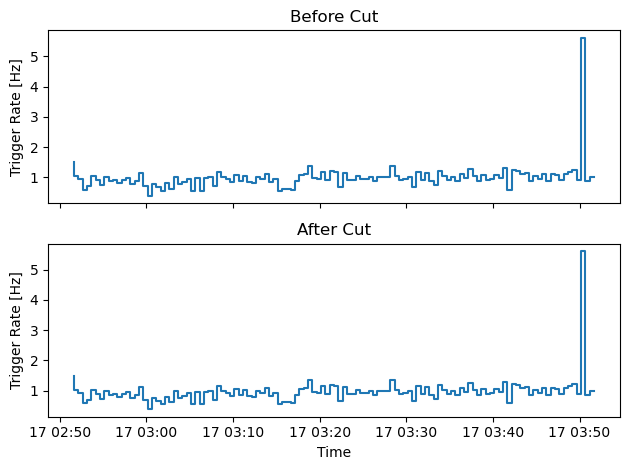

Rate spikes at:  DatetimeIndex(['2026-09-17 03:50:39.969398022-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd Fern (rate_cut 10 Hz)
dp_ph1024*module_252: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/start_2026-09-17T09:51:18Z.dp_ph1024.bpp_2.module_252.seqno_0.pff
Data read in, number of events:  3101
Number of Events with package loss:  0  ( 0.0 %)


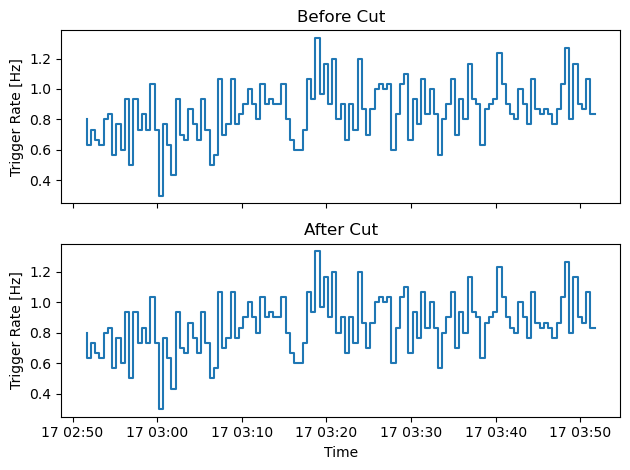

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd Winter (rate_cut 10 Hz)
dp_ph1024*module_253: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/start_2026-09-17T09:51:17Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  3972
Number of Events with package loss:  0  ( 0.0 %)


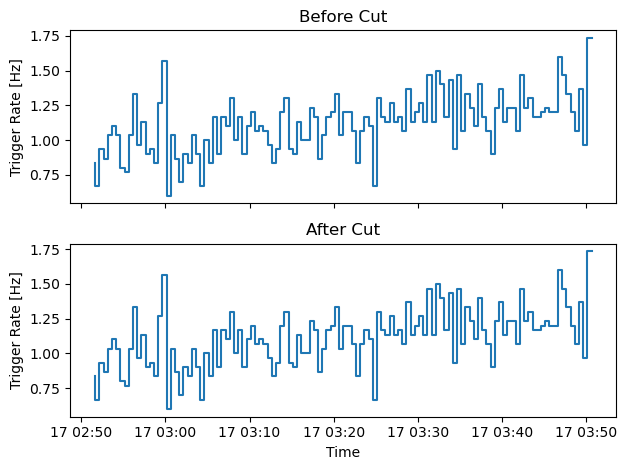

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd Gattini (rate_cut 10 Hz)
dp_ph1024*module_254: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/start_2026-09-17T09:51:17Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  3219
Number of Events with package loss:  0  ( 0.0 %)


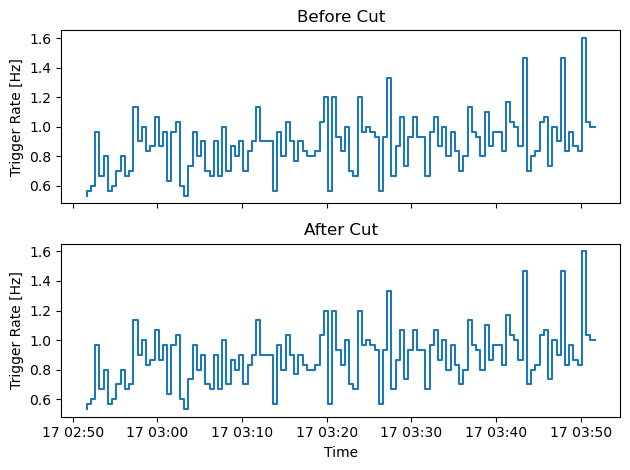

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260917 obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd Heli (rate_cut 10 Hz)
dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/start_2026-09-17T11:09:55Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  7585
Number of Events with package loss:  4  ( 0.05 %)


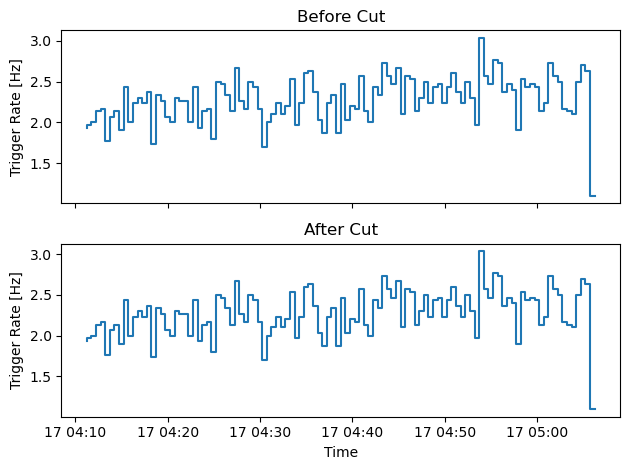

Rate spikes at:  DatetimeIndex(['2026-09-17 04:12:44.453572035-07:00',
               '2026-09-17 04:13:14.453572035-07:00',
               '2026-09-17 04:14:14.453572035-07:00',
               '2026-09-17 04:14:44.453572035-07:00',
               '2026-09-17 04:15:44.453572035-07:00',
               '2026-09-17 04:16:44.453572035-07:00',
               '2026-09-17 04:17:14.453572035-07:00',
               '2026-09-17 04:17:44.453572035-07:00',
               '2026-09-17 04:18:14.453572035-07:00',
               '2026-09-17 04:19:14.453572035-07:00',
               '2026-09-17 04:19:44.453572035-07:00',
               '2026-09-17 04:20:14.453572035-07:00',
               '2026-09-17 04:21:14.453572035-07:00',
               '2026-09-17 04:21:44.453572035-07:00',
               '2026-09-17 04:22:14.453572035-07:00',
               '2026-09-17 04:23:14.453572035-07:00',
               '2026-09-17 04:24:14.453572035-07:00',
               '2026-09-17 04:24:44.453572035-07:00',
           

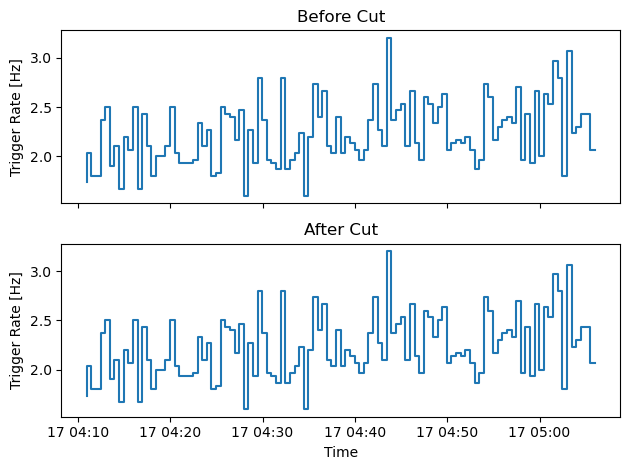

Rate spikes at:  DatetimeIndex(['2026-09-17 04:11:27.402762890-07:00',
               '2026-09-17 04:12:57.402762890-07:00',
               '2026-09-17 04:13:27.402762890-07:00',
               '2026-09-17 04:14:27.402762890-07:00',
               '2026-09-17 04:15:27.402762890-07:00',
               '2026-09-17 04:15:57.402762890-07:00',
               '2026-09-17 04:16:27.402762890-07:00',
               '2026-09-17 04:17:27.402762890-07:00',
               '2026-09-17 04:17:57.402762890-07:00',
               '2026-09-17 04:19:57.402762890-07:00',
               '2026-09-17 04:20:27.402762890-07:00',
               '2026-09-17 04:20:57.402762890-07:00',
               '2026-09-17 04:23:27.402762890-07:00',
               '2026-09-17 04:23:57.402762890-07:00',
               '2026-09-17 04:24:27.402762890-07:00',
               '2026-09-17 04:25:57.402762890-07:00',
               '2026-09-17 04:26:27.402762890-07:00',
               '2026-09-17 04:26:57.402762890-07:00',
           

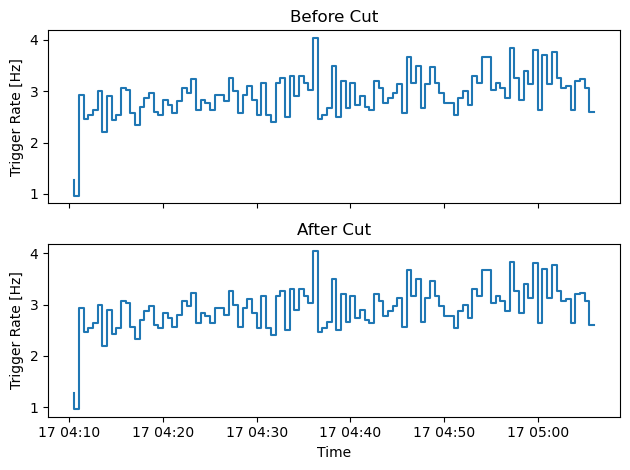

Rate spikes at:  DatetimeIndex(['2026-09-17 04:11:30.033783913-07:00',
               '2026-09-17 04:12:00.033783913-07:00',
               '2026-09-17 04:12:30.033783913-07:00',
               '2026-09-17 04:13:00.033783913-07:00',
               '2026-09-17 04:13:30.033783913-07:00',
               '2026-09-17 04:14:00.033783913-07:00',
               '2026-09-17 04:14:30.033783913-07:00',
               '2026-09-17 04:15:00.033783913-07:00',
               '2026-09-17 04:15:30.033783913-07:00',
               '2026-09-17 04:16:00.033783913-07:00',
               ...
               '2026-09-17 05:01:30.033783913-07:00',
               '2026-09-17 05:02:00.033783913-07:00',
               '2026-09-17 05:02:30.033783913-07:00',
               '2026-09-17 05:03:00.033783913-07:00',
               '2026-09-17 05:03:30.033783913-07:00',
               '2026-09-17 05:04:00.033783913-07:00',
               '2026-09-17 05:04:30.033783913-07:00',
               '2026-09-17 05:05:00.033783913-

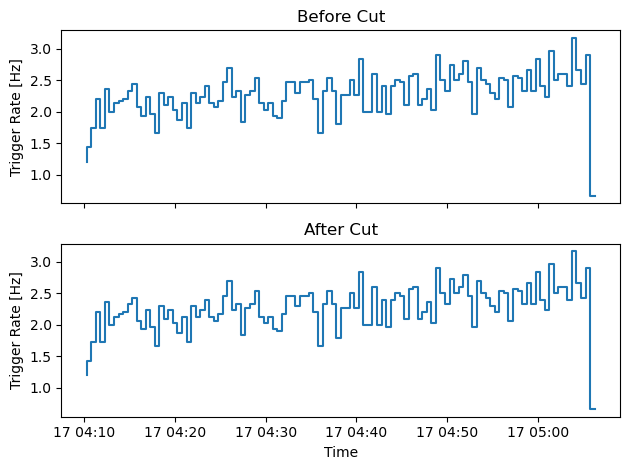

Rate spikes at:  DatetimeIndex(['2026-09-17 04:11:45.932566881-07:00',
               '2026-09-17 04:12:45.932566881-07:00',
               '2026-09-17 04:13:45.932566881-07:00',
               '2026-09-17 04:14:15.932566881-07:00',
               '2026-09-17 04:14:45.932566881-07:00',
               '2026-09-17 04:15:15.932566881-07:00',
               '2026-09-17 04:15:45.932566881-07:00',
               '2026-09-17 04:16:15.932566881-07:00',
               '2026-09-17 04:17:15.932566881-07:00',
               '2026-09-17 04:18:45.932566881-07:00',
               '2026-09-17 04:19:15.932566881-07:00',
               '2026-09-17 04:19:45.932566881-07:00',
               '2026-09-17 04:20:15.932566881-07:00',
               '2026-09-17 04:21:15.932566881-07:00',
               '2026-09-17 04:22:15.932566881-07:00',
               '2026-09-17 04:22:45.932566881-07:00',
               '2026-09-17 04:23:15.932566881-07:00',
               '2026-09-17 04:23:45.932566881-07:00',
           

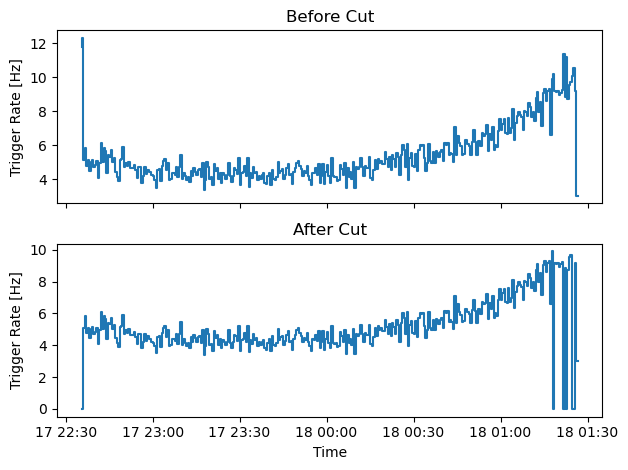

Rate spikes at:  DatetimeIndex(['2026-09-17 22:35:34.582803011-07:00',
               '2026-09-17 22:36:04.582803011-07:00',
               '2026-09-17 22:36:34.582803011-07:00',
               '2026-09-17 22:37:04.582803011-07:00',
               '2026-09-17 22:37:34.582803011-07:00',
               '2026-09-17 22:38:04.582803011-07:00',
               '2026-09-17 22:38:34.582803011-07:00',
               '2026-09-17 22:39:04.582803011-07:00',
               '2026-09-17 22:39:34.582803011-07:00',
               '2026-09-17 22:40:04.582803011-07:00',
               ...
               '2026-09-18 01:22:04.582803011-07:00',
               '2026-09-18 01:22:34.582803011-07:00',
               '2026-09-18 01:23:04.582803011-07:00',
               '2026-09-18 01:23:34.582803011-07:00',
               '2026-09-18 01:24:04.582803011-07:00',
               '2026-09-18 01:24:34.582803011-07:00',
               '2026-09-18 01:25:04.582803011-07:00',
               '2026-09-18 01:25:34.582803011-

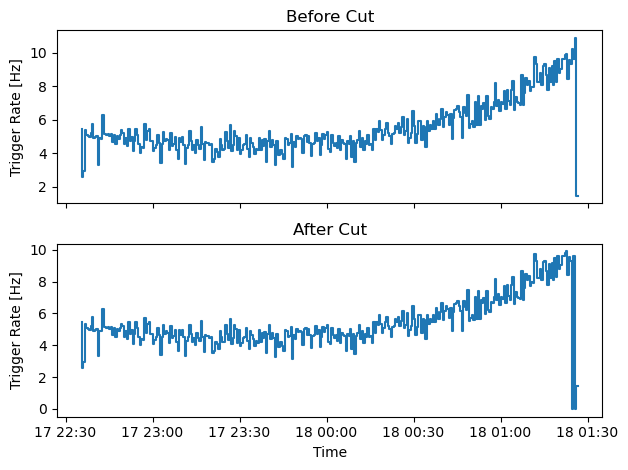

Rate spikes at:  DatetimeIndex(['2026-09-17 22:35:35.496624947-07:00',
               '2026-09-17 22:36:05.496624947-07:00',
               '2026-09-17 22:36:35.496624947-07:00',
               '2026-09-17 22:37:05.496624947-07:00',
               '2026-09-17 22:37:35.496624947-07:00',
               '2026-09-17 22:38:05.496624947-07:00',
               '2026-09-17 22:38:35.496624947-07:00',
               '2026-09-17 22:39:05.496624947-07:00',
               '2026-09-17 22:39:35.496624947-07:00',
               '2026-09-17 22:40:05.496624947-07:00',
               ...
               '2026-09-18 01:21:35.496624947-07:00',
               '2026-09-18 01:22:05.496624947-07:00',
               '2026-09-18 01:22:35.496624947-07:00',
               '2026-09-18 01:23:05.496624947-07:00',
               '2026-09-18 01:23:35.496624947-07:00',
               '2026-09-18 01:24:05.496624947-07:00',
               '2026-09-18 01:24:35.496624947-07:00',
               '2026-09-18 01:25:05.496624947-

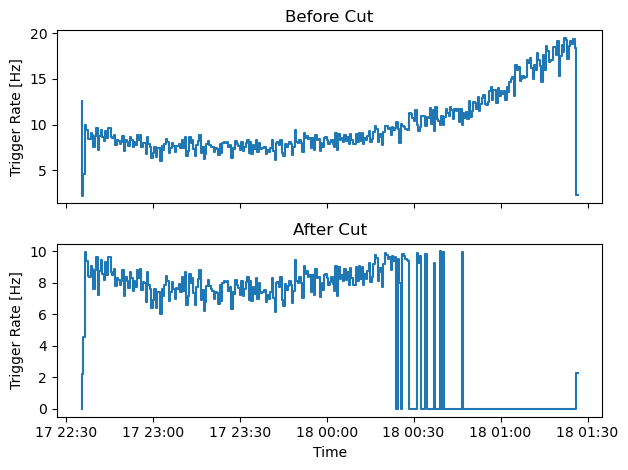

Rate spikes at:  DatetimeIndex(['2026-09-17 22:35:33.180339098-07:00',
               '2026-09-17 22:36:03.180339098-07:00',
               '2026-09-17 22:36:33.180339098-07:00',
               '2026-09-17 22:37:03.180339098-07:00',
               '2026-09-17 22:37:33.180339098-07:00',
               '2026-09-17 22:38:03.180339098-07:00',
               '2026-09-17 22:38:33.180339098-07:00',
               '2026-09-17 22:39:03.180339098-07:00',
               '2026-09-17 22:39:33.180339098-07:00',
               '2026-09-17 22:40:03.180339098-07:00',
               ...
               '2026-09-18 01:22:03.180339098-07:00',
               '2026-09-18 01:22:33.180339098-07:00',
               '2026-09-18 01:23:03.180339098-07:00',
               '2026-09-18 01:23:33.180339098-07:00',
               '2026-09-18 01:24:03.180339098-07:00',
               '2026-09-18 01:24:33.180339098-07:00',
               '2026-09-18 01:25:03.180339098-07:00',
               '2026-09-18 01:25:33.180339098-

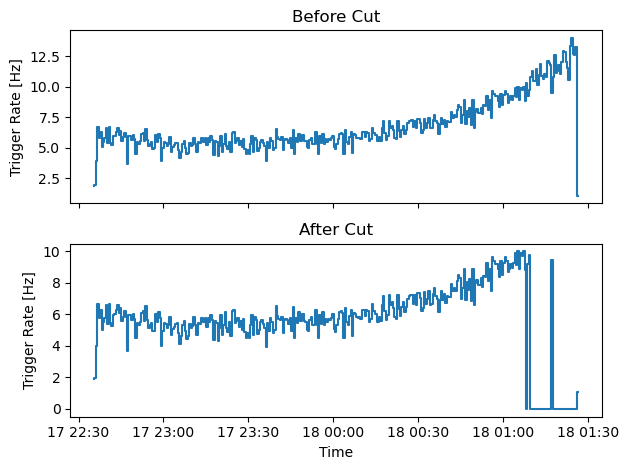

Rate spikes at:  DatetimeIndex(['2026-09-17 22:36:36.022135019-07:00',
               '2026-09-17 22:37:06.022135019-07:00',
               '2026-09-17 22:37:36.022135019-07:00',
               '2026-09-17 22:38:06.022135019-07:00',
               '2026-09-17 22:38:36.022135019-07:00',
               '2026-09-17 22:39:06.022135019-07:00',
               '2026-09-17 22:39:36.022135019-07:00',
               '2026-09-17 22:40:06.022135019-07:00',
               '2026-09-17 22:40:36.022135019-07:00',
               '2026-09-17 22:41:06.022135019-07:00',
               ...
               '2026-09-18 01:21:36.022135019-07:00',
               '2026-09-18 01:22:06.022135019-07:00',
               '2026-09-18 01:22:36.022135019-07:00',
               '2026-09-18 01:23:06.022135019-07:00',
               '2026-09-18 01:23:36.022135019-07:00',
               '2026-09-18 01:24:06.022135019-07:00',
               '2026-09-18 01:24:36.022135019-07:00',
               '2026-09-18 01:25:06.022135019-

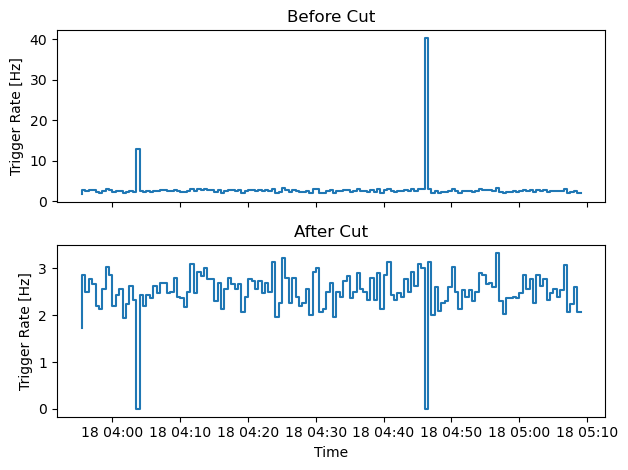

Rate spikes at:  DatetimeIndex(['2026-09-18 03:56:01.744538069-07:00',
               '2026-09-18 03:56:31.744538069-07:00',
               '2026-09-18 03:57:01.744538069-07:00',
               '2026-09-18 03:57:31.744538069-07:00',
               '2026-09-18 03:58:01.744538069-07:00',
               '2026-09-18 03:58:31.744538069-07:00',
               '2026-09-18 03:59:01.744538069-07:00',
               '2026-09-18 03:59:31.744538069-07:00',
               '2026-09-18 04:00:01.744538069-07:00',
               '2026-09-18 04:00:31.744538069-07:00',
               ...
               '2026-09-18 05:04:31.744538069-07:00',
               '2026-09-18 05:05:01.744538069-07:00',
               '2026-09-18 05:05:31.744538069-07:00',
               '2026-09-18 05:06:01.744538069-07:00',
               '2026-09-18 05:06:31.744538069-07:00',
               '2026-09-18 05:07:01.744538069-07:00',
               '2026-09-18 05:07:31.744538069-07:00',
               '2026-09-18 05:08:01.744538069-

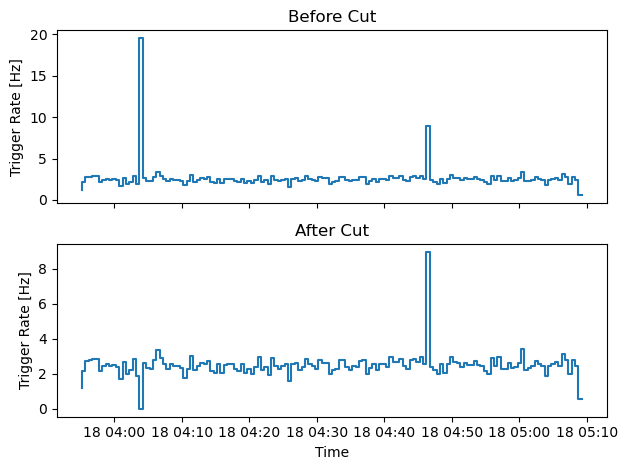

Rate spikes at:  DatetimeIndex(['2026-09-18 03:55:44.332139969-07:00',
               '2026-09-18 03:56:14.332139969-07:00',
               '2026-09-18 03:56:44.332139969-07:00',
               '2026-09-18 03:57:14.332139969-07:00',
               '2026-09-18 03:57:44.332139969-07:00',
               '2026-09-18 03:58:14.332139969-07:00',
               '2026-09-18 03:58:44.332139969-07:00',
               '2026-09-18 03:59:14.332139969-07:00',
               '2026-09-18 03:59:44.332139969-07:00',
               '2026-09-18 04:00:14.332139969-07:00',
               ...
               '2026-09-18 05:03:14.332139969-07:00',
               '2026-09-18 05:03:44.332139969-07:00',
               '2026-09-18 05:04:44.332139969-07:00',
               '2026-09-18 05:05:14.332139969-07:00',
               '2026-09-18 05:05:44.332139969-07:00',
               '2026-09-18 05:06:14.332139969-07:00',
               '2026-09-18 05:06:44.332139969-07:00',
               '2026-09-18 05:07:14.332139969-

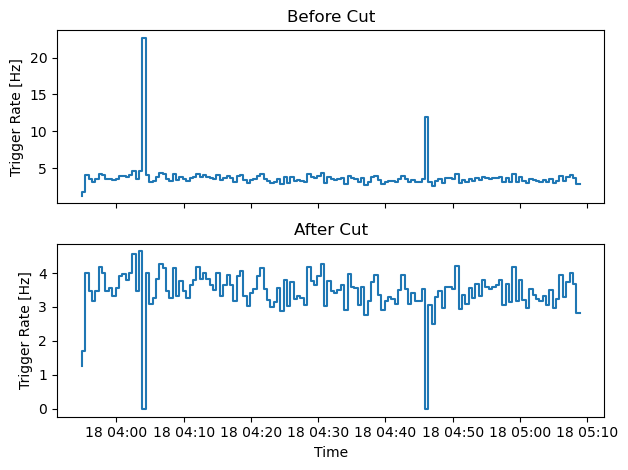

Rate spikes at:  DatetimeIndex(['2026-09-18 03:55:51.851762056-07:00',
               '2026-09-18 03:56:21.851762056-07:00',
               '2026-09-18 03:56:51.851762056-07:00',
               '2026-09-18 03:57:21.851762056-07:00',
               '2026-09-18 03:57:51.851762056-07:00',
               '2026-09-18 03:58:21.851762056-07:00',
               '2026-09-18 03:58:51.851762056-07:00',
               '2026-09-18 03:59:21.851762056-07:00',
               '2026-09-18 03:59:51.851762056-07:00',
               '2026-09-18 04:00:21.851762056-07:00',
               ...
               '2026-09-18 05:04:21.851762056-07:00',
               '2026-09-18 05:04:51.851762056-07:00',
               '2026-09-18 05:05:21.851762056-07:00',
               '2026-09-18 05:05:51.851762056-07:00',
               '2026-09-18 05:06:21.851762056-07:00',
               '2026-09-18 05:06:51.851762056-07:00',
               '2026-09-18 05:07:21.851762056-07:00',
               '2026-09-18 05:07:51.851762056-

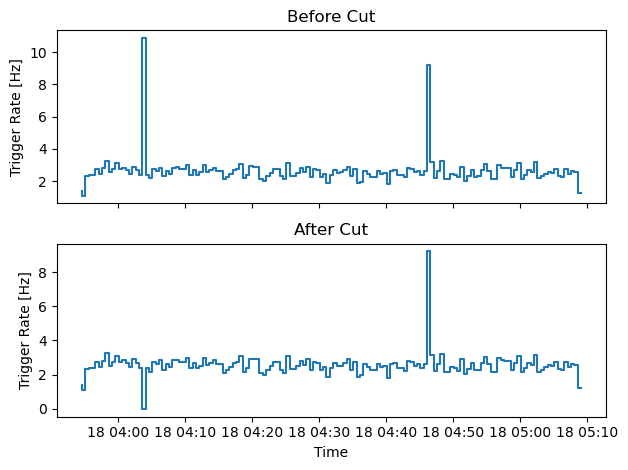

Rate spikes at:  DatetimeIndex(['2026-09-18 03:55:36.168334007-07:00',
               '2026-09-18 03:56:06.168334007-07:00',
               '2026-09-18 03:56:36.168334007-07:00',
               '2026-09-18 03:57:06.168334007-07:00',
               '2026-09-18 03:57:36.168334007-07:00',
               '2026-09-18 03:58:06.168334007-07:00',
               '2026-09-18 03:58:36.168334007-07:00',
               '2026-09-18 03:59:06.168334007-07:00',
               '2026-09-18 03:59:36.168334007-07:00',
               '2026-09-18 04:00:06.168334007-07:00',
               ...
               '2026-09-18 05:04:06.168334007-07:00',
               '2026-09-18 05:04:36.168334007-07:00',
               '2026-09-18 05:05:06.168334007-07:00',
               '2026-09-18 05:05:36.168334007-07:00',
               '2026-09-18 05:06:06.168334007-07:00',
               '2026-09-18 05:06:36.168334007-07:00',
               '2026-09-18 05:07:06.168334007-07:00',
               '2026-09-18 05:07:36.168334007-

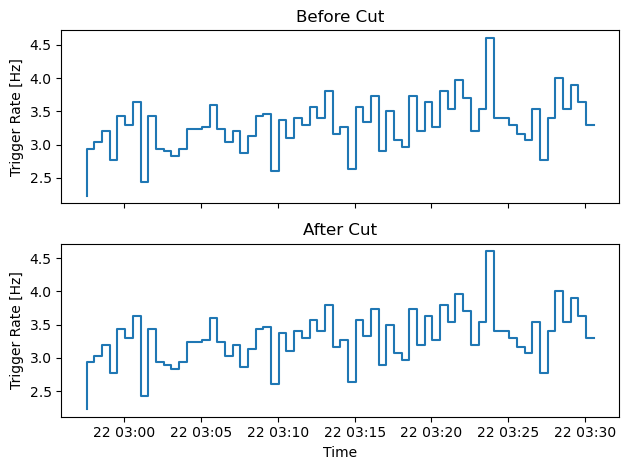

Rate spikes at:  DatetimeIndex(['2026-09-22 02:57:33.826443911-07:00',
               '2026-09-22 02:58:03.826443911-07:00',
               '2026-09-22 02:58:33.826443911-07:00',
               '2026-09-22 02:59:03.826443911-07:00',
               '2026-09-22 02:59:33.826443911-07:00',
               '2026-09-22 03:00:03.826443911-07:00',
               '2026-09-22 03:00:33.826443911-07:00',
               '2026-09-22 03:01:03.826443911-07:00',
               '2026-09-22 03:01:33.826443911-07:00',
               '2026-09-22 03:02:03.826443911-07:00',
               '2026-09-22 03:02:33.826443911-07:00',
               '2026-09-22 03:03:03.826443911-07:00',
               '2026-09-22 03:03:33.826443911-07:00',
               '2026-09-22 03:04:03.826443911-07:00',
               '2026-09-22 03:04:33.826443911-07:00',
               '2026-09-22 03:05:03.826443911-07:00',
               '2026-09-22 03:05:33.826443911-07:00',
               '2026-09-22 03:06:03.826443911-07:00',
           

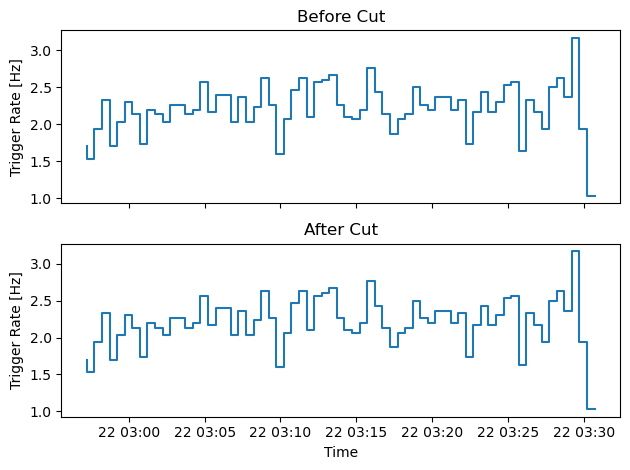

Rate spikes at:  DatetimeIndex(['2026-09-22 02:58:43.371593952-07:00',
               '2026-09-22 02:59:43.371593952-07:00',
               '2026-09-22 03:00:13.371593952-07:00',
               '2026-09-22 03:00:43.371593952-07:00',
               '2026-09-22 03:01:43.371593952-07:00',
               '2026-09-22 03:02:13.371593952-07:00',
               '2026-09-22 03:02:43.371593952-07:00',
               '2026-09-22 03:03:13.371593952-07:00',
               '2026-09-22 03:03:43.371593952-07:00',
               '2026-09-22 03:04:13.371593952-07:00',
               '2026-09-22 03:04:43.371593952-07:00',
               '2026-09-22 03:05:13.371593952-07:00',
               '2026-09-22 03:05:43.371593952-07:00',
               '2026-09-22 03:06:13.371593952-07:00',
               '2026-09-22 03:06:43.371593952-07:00',
               '2026-09-22 03:07:13.371593952-07:00',
               '2026-09-22 03:07:43.371593952-07:00',
               '2026-09-22 03:08:13.371593952-07:00',
           

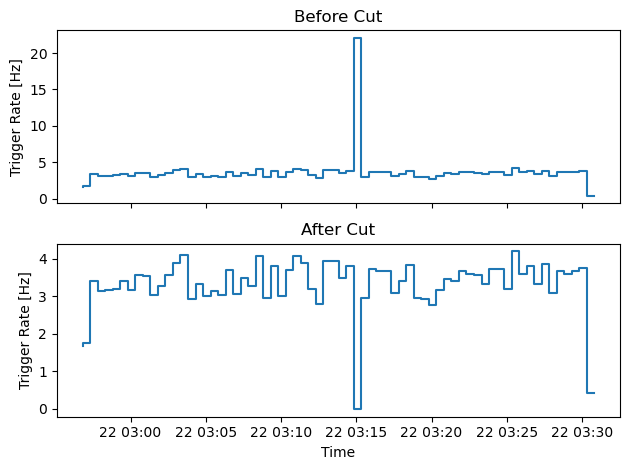

Rate spikes at:  DatetimeIndex(['2026-09-22 02:57:48.897461891-07:00',
               '2026-09-22 02:58:18.897461891-07:00',
               '2026-09-22 02:58:48.897461891-07:00',
               '2026-09-22 02:59:18.897461891-07:00',
               '2026-09-22 02:59:48.897461891-07:00',
               '2026-09-22 03:00:18.897461891-07:00',
               '2026-09-22 03:00:48.897461891-07:00',
               '2026-09-22 03:01:18.897461891-07:00',
               '2026-09-22 03:01:48.897461891-07:00',
               '2026-09-22 03:02:18.897461891-07:00',
               '2026-09-22 03:02:48.897461891-07:00',
               '2026-09-22 03:03:18.897461891-07:00',
               '2026-09-22 03:03:48.897461891-07:00',
               '2026-09-22 03:04:18.897461891-07:00',
               '2026-09-22 03:04:48.897461891-07:00',
               '2026-09-22 03:05:18.897461891-07:00',
               '2026-09-22 03:05:48.897461891-07:00',
               '2026-09-22 03:06:18.897461891-07:00',
           

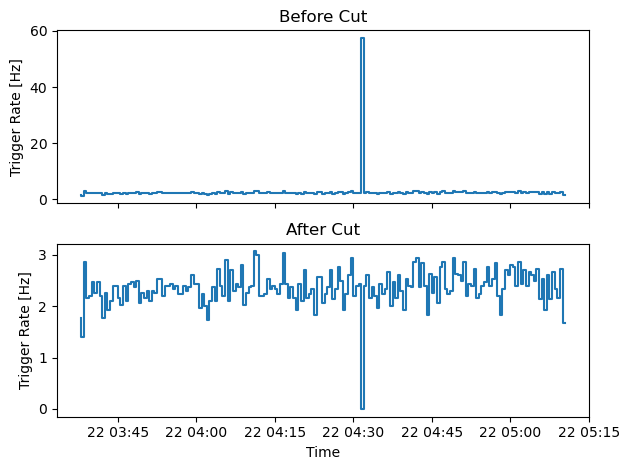

Rate spikes at:  DatetimeIndex(['2026-09-22 03:38:58.508275032-07:00',
               '2026-09-22 03:39:28.508275032-07:00',
               '2026-09-22 03:39:58.508275032-07:00',
               '2026-09-22 03:40:28.508275032-07:00',
               '2026-09-22 03:40:58.508275032-07:00',
               '2026-09-22 03:41:28.508275032-07:00',
               '2026-09-22 03:41:58.508275032-07:00',
               '2026-09-22 03:42:58.508275032-07:00',
               '2026-09-22 03:43:58.508275032-07:00',
               '2026-09-22 03:44:28.508275032-07:00',
               ...
               '2026-09-22 05:04:58.508275032-07:00',
               '2026-09-22 05:05:28.508275032-07:00',
               '2026-09-22 05:05:58.508275032-07:00',
               '2026-09-22 05:06:28.508275032-07:00',
               '2026-09-22 05:07:28.508275032-07:00',
               '2026-09-22 05:07:58.508275032-07:00',
               '2026-09-22 05:08:28.508275032-07:00',
               '2026-09-22 05:08:58.508275032-

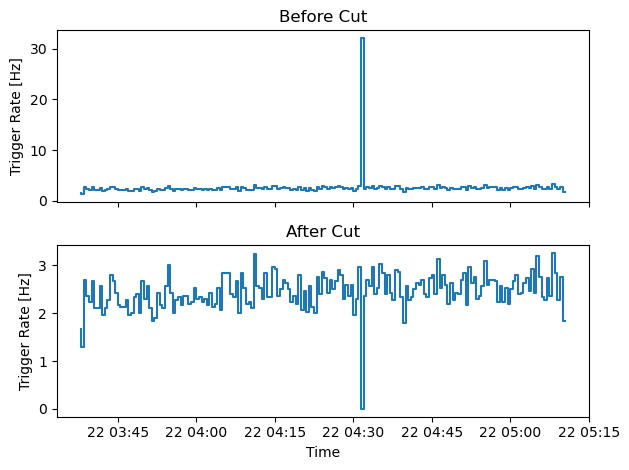

Rate spikes at:  DatetimeIndex(['2026-09-22 03:38:58.057598114-07:00',
               '2026-09-22 03:39:28.057598114-07:00',
               '2026-09-22 03:39:58.057598114-07:00',
               '2026-09-22 03:40:28.057598114-07:00',
               '2026-09-22 03:40:58.057598114-07:00',
               '2026-09-22 03:41:28.057598114-07:00',
               '2026-09-22 03:41:58.057598114-07:00',
               '2026-09-22 03:42:58.057598114-07:00',
               '2026-09-22 03:43:28.057598114-07:00',
               '2026-09-22 03:43:58.057598114-07:00',
               ...
               '2026-09-22 05:05:28.057598114-07:00',
               '2026-09-22 05:05:58.057598114-07:00',
               '2026-09-22 05:06:28.057598114-07:00',
               '2026-09-22 05:06:58.057598114-07:00',
               '2026-09-22 05:07:28.057598114-07:00',
               '2026-09-22 05:07:58.057598114-07:00',
               '2026-09-22 05:08:28.057598114-07:00',
               '2026-09-22 05:08:58.057598114-

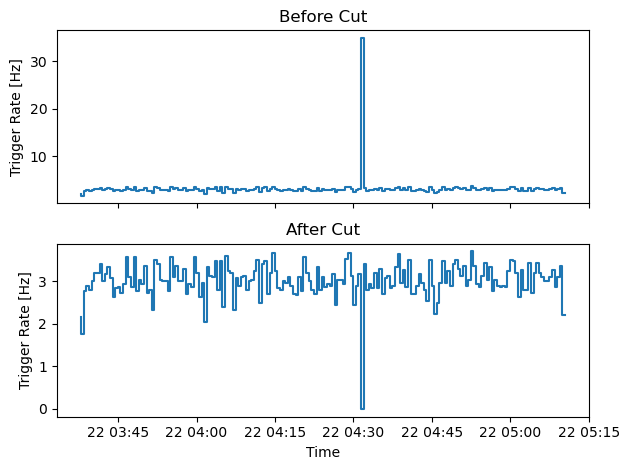

Rate spikes at:  DatetimeIndex(['2026-09-22 03:37:56.437613964-07:00',
               '2026-09-22 03:38:56.437613964-07:00',
               '2026-09-22 03:39:26.437613964-07:00',
               '2026-09-22 03:39:56.437613964-07:00',
               '2026-09-22 03:40:26.437613964-07:00',
               '2026-09-22 03:40:56.437613964-07:00',
               '2026-09-22 03:41:26.437613964-07:00',
               '2026-09-22 03:41:56.437613964-07:00',
               '2026-09-22 03:42:26.437613964-07:00',
               '2026-09-22 03:42:56.437613964-07:00',
               ...
               '2026-09-22 05:05:56.437613964-07:00',
               '2026-09-22 05:06:26.437613964-07:00',
               '2026-09-22 05:06:56.437613964-07:00',
               '2026-09-22 05:07:26.437613964-07:00',
               '2026-09-22 05:07:56.437613964-07:00',
               '2026-09-22 05:08:26.437613964-07:00',
               '2026-09-22 05:08:56.437613964-07:00',
               '2026-09-22 05:09:26.437613964-

In [6]:
if RAW_DIAGNOSTICS:
    for date in DATES:
        for run_dir in discover_runs(RAW_DATA_DIR / date):
            for module, info in TELESCOPE_MODULES.items():
                if any(run_dir.glob(f"*{DATA_PRODUCT}*{module}*.pff")):
                    print(f"{date} {run_dir.name} {info['name']} (rate_cut {info['rate_cut']} Hz)")
                    coinc.load_telescope_tv(f"{DATA_PRODUCT}*{module}", run_dir, info["rate_cut"], plotting=True)

# Image processing
Nights already processed are skipped unless `REPROCESS`; each telescope's settings are checked against its
`processing.json`.

In [7]:
for date in DATES:
    ev.process_night(
        RAW_DATA_DIR / date, OUTPUT_DIR, date, TELESCOPE_MODULES, data_product=DATA_PRODUCT,
        image_threshold=IMAGE_THRESHOLD, border_threshold=BORDER_THRESHOLD, keep_brightest_island=KEEP_BRIGHTEST_ISLAND,
        reprocess=REPROCESS,
    )

dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/start_2026-09-17T09:51:18Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  3555
Number of Events with package loss:  0  ( 0.0 %)
Rate spikes at:  DatetimeIndex(['2026-09-17 03:50:39.969398022-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/start_2026-09-17T11:09:55Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  7585
Number of Events with package loss:  4  ( 0.05 %)
Rate spikes at:  DatetimeIndex(['2026-09-17 04:12:44.453572035-07:00',
               '2

# Diagnostics
## Processed data
Every telescope and source written, per night. Frames are after the packet-loss and spike cuts; Cleaned is the
fraction with any pixel left after cleaning. A row with no Source is a telescope with no usable frames that night.

In [8]:
products = dg.product_table(OUTPUT_DIR, DATES)
products.drop(columns="Settings")

,Date,Telescope,Source,Frames,Start,End,Hours,Rate,Cleaned,GainSource,MB
0,20260917,Fern,Crab,10528,2026-09-17 09:51:26+00:00,2026-09-17 12:06:08+00:00,2.25,1.30,0.863,flat,130.6
1,20260917,Gattini,Crab,10942,2026-09-17 09:51:24+00:00,2026-09-17 12:06:07+00:00,2.25,1.35,0.764,flat,135.8
2,20260917,Heli,Crab,11136,2026-09-17 09:51:24+00:00,2026-09-17 12:06:10+00:00,2.25,1.38,0.880,flat,138.2
3,20260917,Winter,Crab,13797,2026-09-17 09:51:23+00:00,2026-09-17 12:06:05+00:00,2.25,1.71,0.751,flat,171.2
4,20260918,Fern,Crab,11065,2026-09-18 10:54:59+00:00,2026-09-18 12:09:08+00:00,1.24,2.49,0.765,alt,137.3
5,20260918,Fern,MGRO_J2019_37,55937,2026-09-18 05:35:20+00:00,2026-09-18 08:26:25+00:00,2.85,5.45,0.345,alt,694.1
6,20260918,Gattini,Crab,11473,2026-09-18 10:54:21+00:00,2026-09-18 12:09:06+00:00,1.25,2.56,0.653,alt,142.4
7,20260918,Gattini,MGRO_J2019_37,58018,2026-09-18 05:35:21+00:00,2026-09-18 08:26:23+00:00,2.85,5.65,0.289,alt,719.9
8,20260918,Heli,Crab,11128,2026-09-18 10:55:16+00:00,2026-09-18 12:09:09+00:00,1.23,2.51,0.783,alt,138.1
9,20260918,Heli,MGRO_J2019_37,53297,2026-09-18 05:36:19+00:00,2026-09-18 08:26:27+00:00,2.84,5.22,0.378,alt,661.3


## Gain maps
A gain map is each pixel's gain relative to the camera average (mean 1), made once per telescope, source and night;
cleaned images are divided by it. It comes from the pedvar (pedestal variance) of two different star fields: a star
inflates the pedvar of the pixels it falls on, so where the two fields' pedvars differ by more than 3 sigma the lower
one is used, otherwise their average (see `heap.make_gain_map.gain_from_pedvars()`).

The second star field is the first of these that exists, and each map below is titled with which one was used:

| Title | Second star field | |
|---|---|---|
| `own` | the same source on the other side of the meridian flip, same night | the camera is rotated 180 deg, so stars land on different pixels |
| `alt` | the run of another source that night closest in time, either flip side | when the source was only observed on one side of the flip |
| `prior_night:<date>` | none; reuses the telescope's gain map from the latest earlier night in `OUTPUT_DIR` that wasn't `flat` | when no other source was observed that night |
| `flat` | none; every pixel is 1, i.e. no gain correction | e.g. the first night processed for this telescope |

`alt` and `prior_night` depend on which other runs and nights are in the data, so processing a subset of it can change
the gain maps. `alt` maps are titled with the other source and its flip side; the calibration plots below give each
map's full caption (see `heap.process_dataset.resolve_gain_map()`).

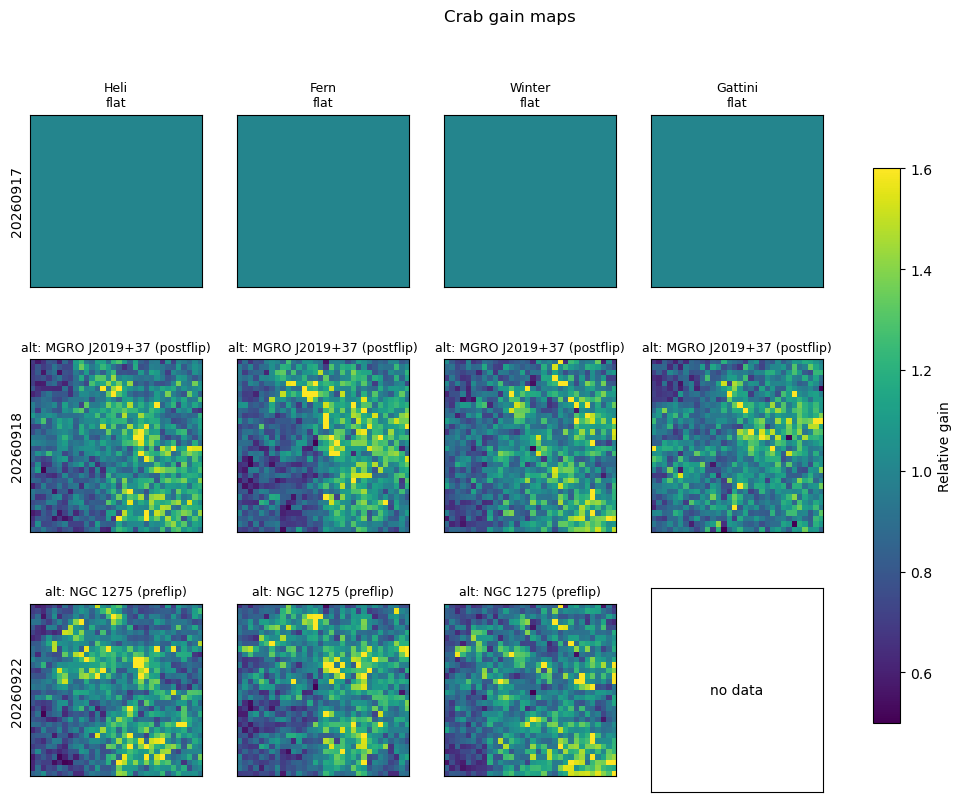

In [9]:
dg.plot_gain_maps(OUTPUT_DIR, DATES, TELESCOPES, SOURCE)
plt.show()

## Calibrations
Per telescope and night: the camera's pedestal and pedvar over time, then the pedestal and pedvar maps applied in each
window they were recomputed in (every 600 s, see `heap.process_dataset.build_calibrations()`), each on one color
scale across the night so changes stand out (e.g. a star raising the pedvar of the pixels it's on).

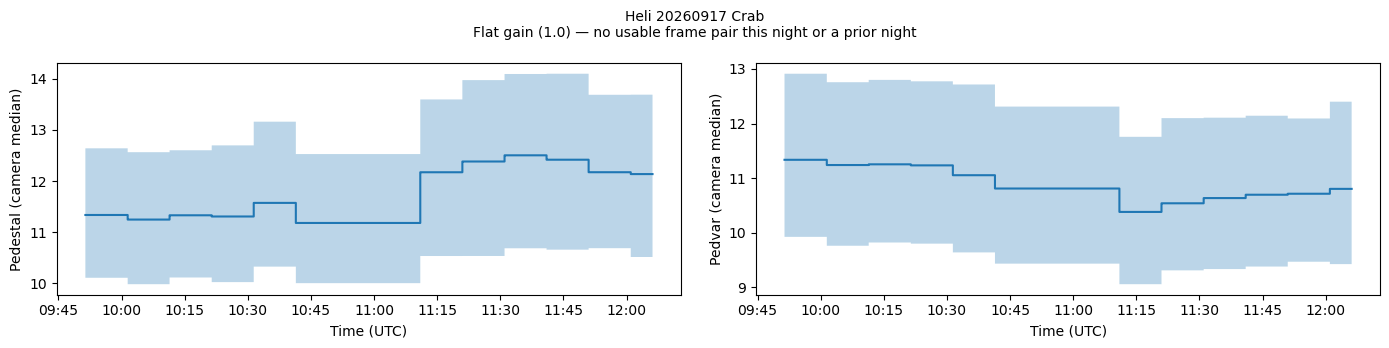

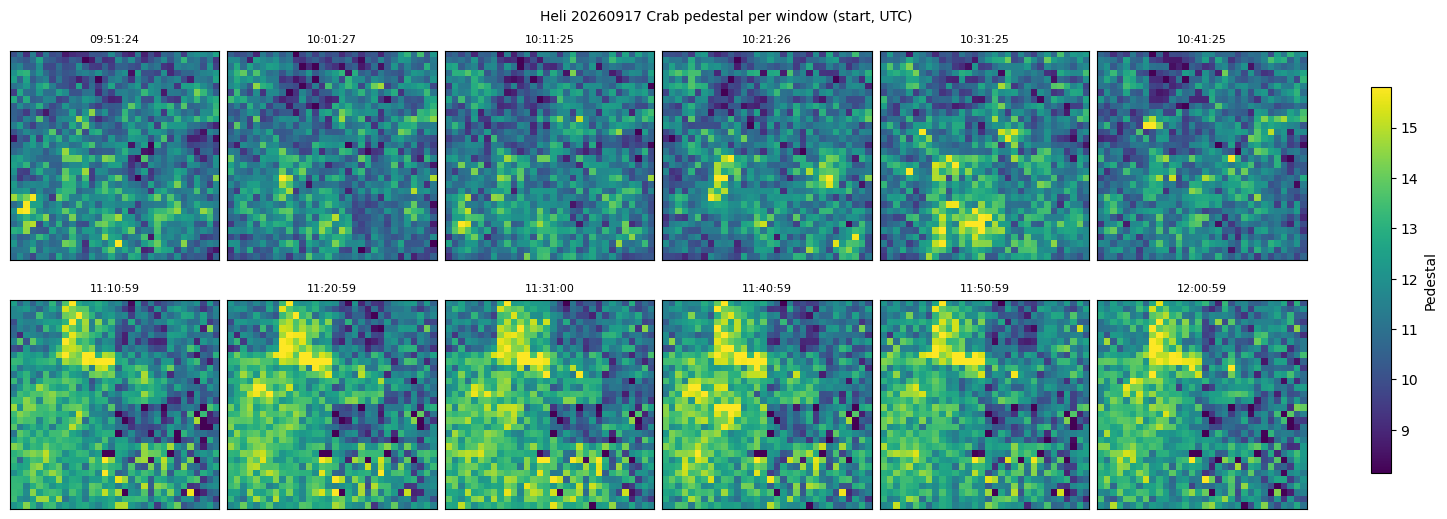

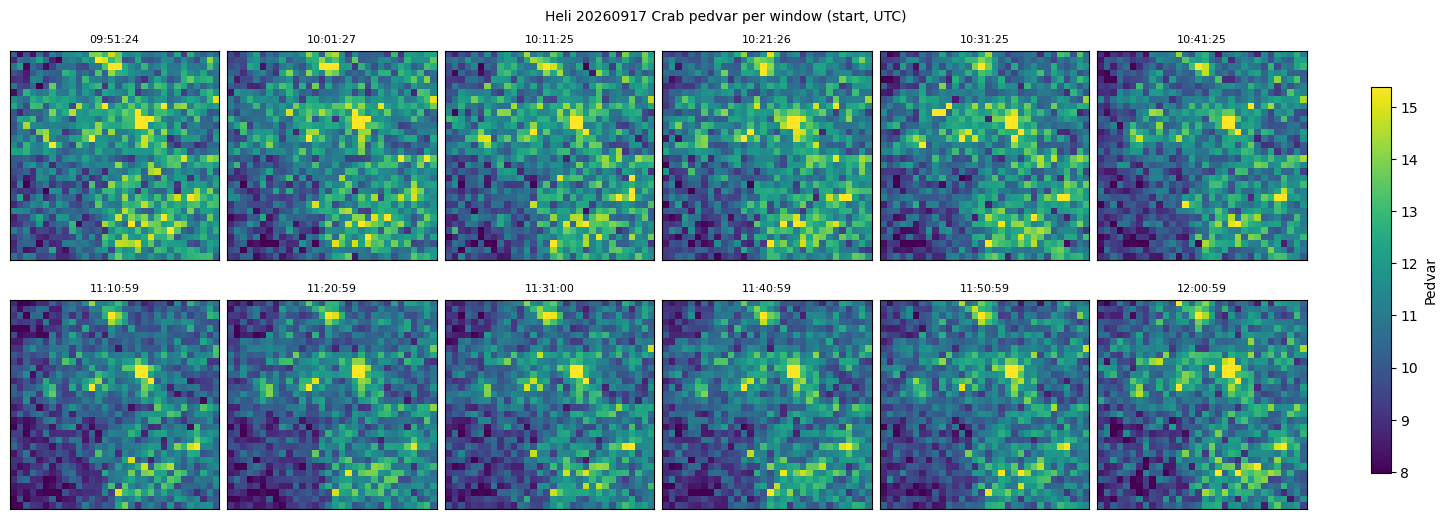

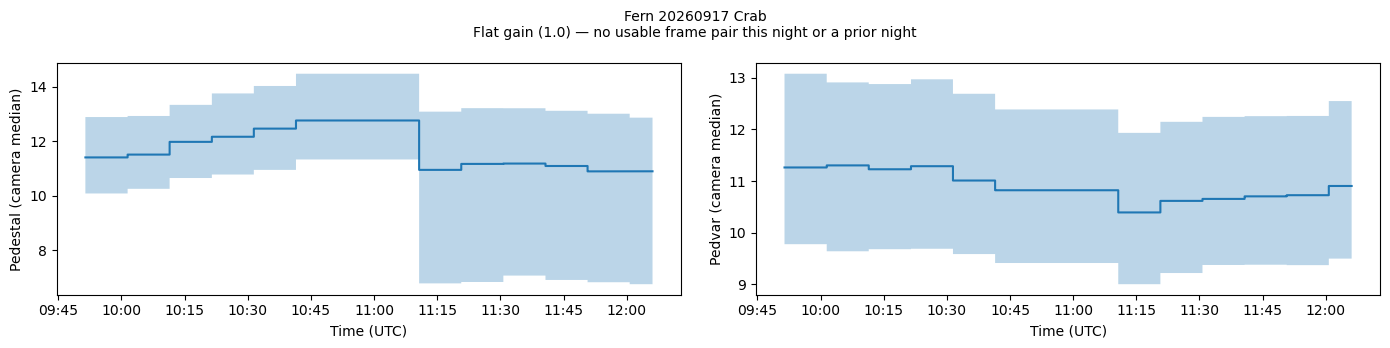

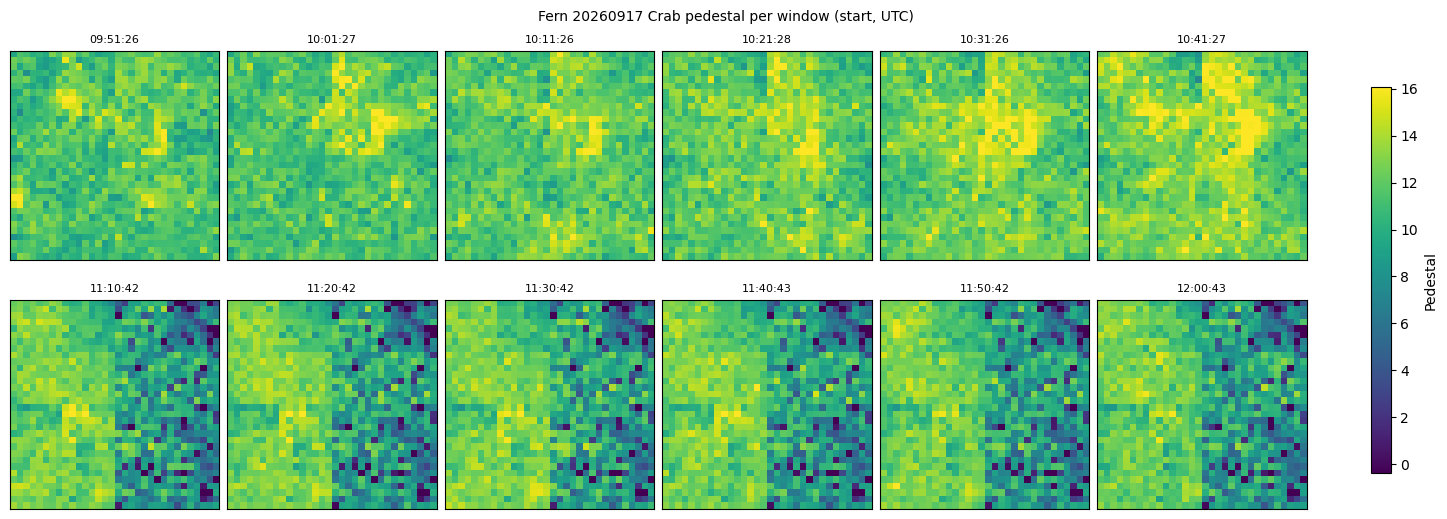

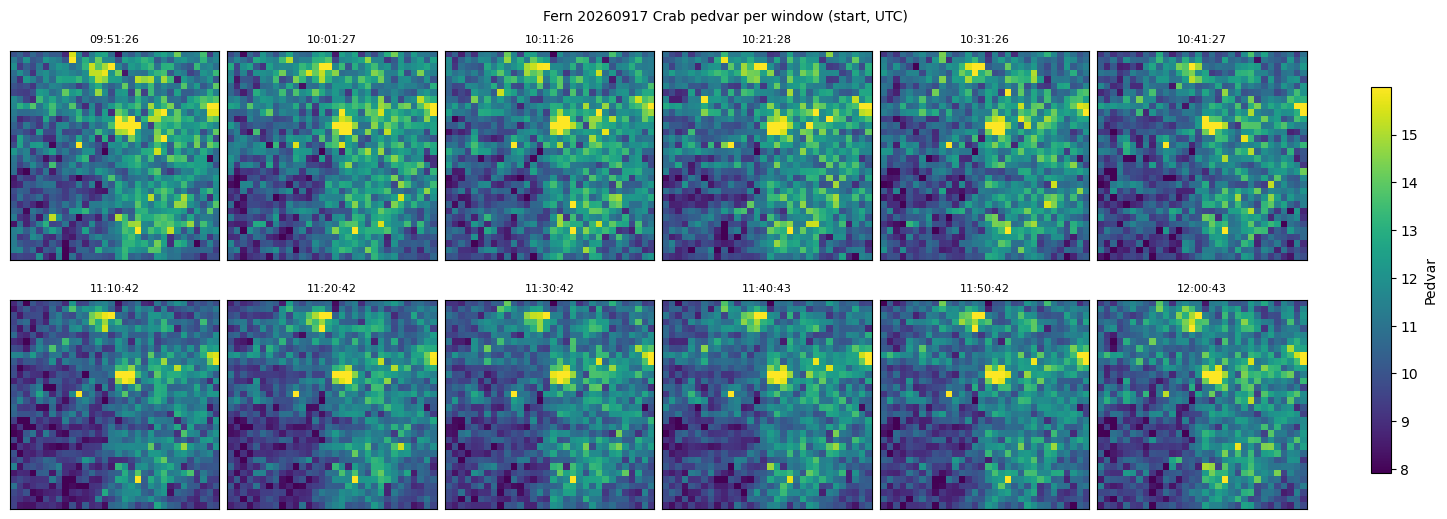

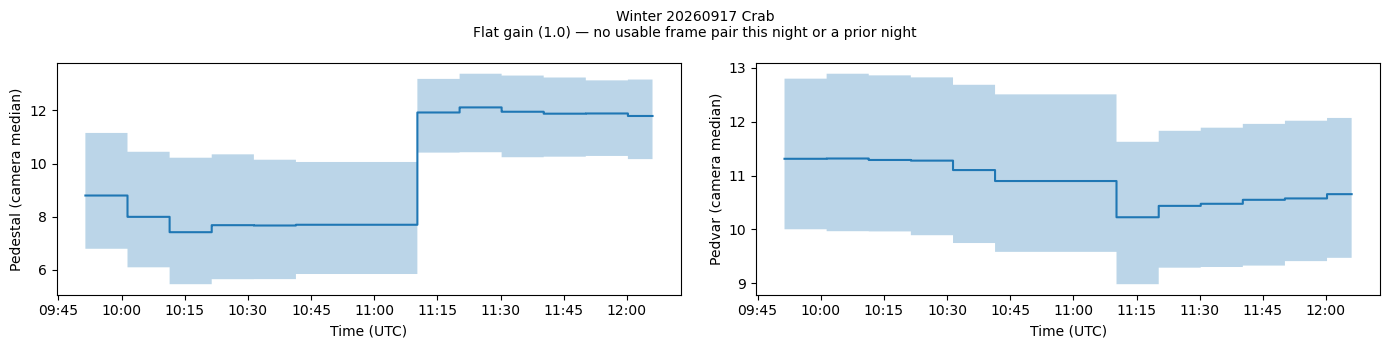

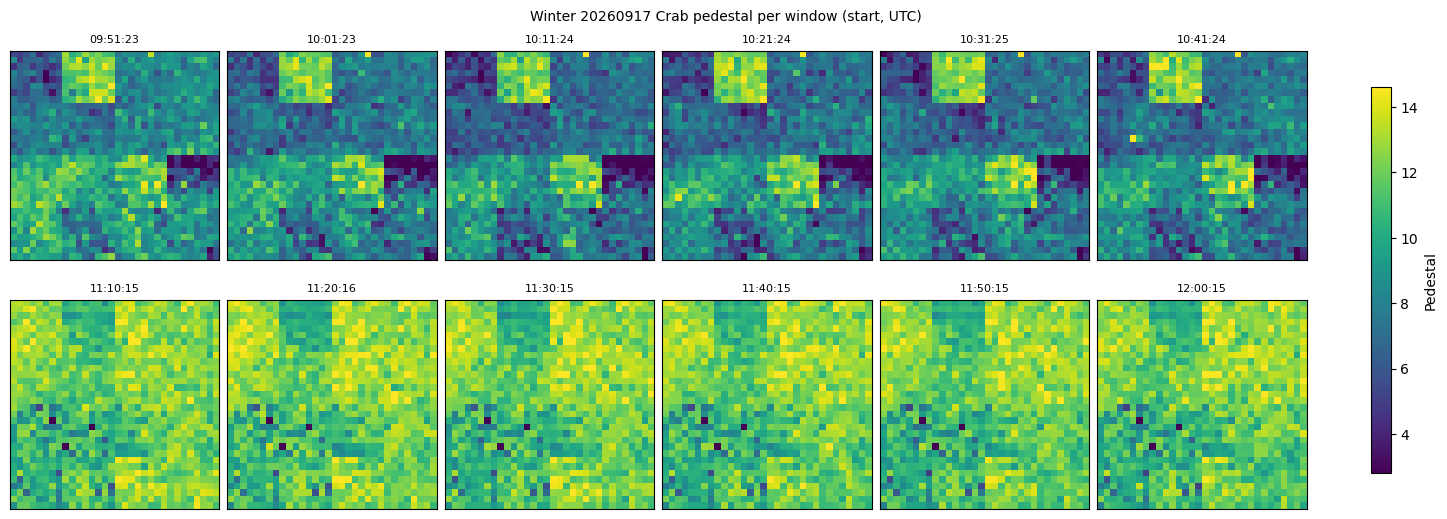

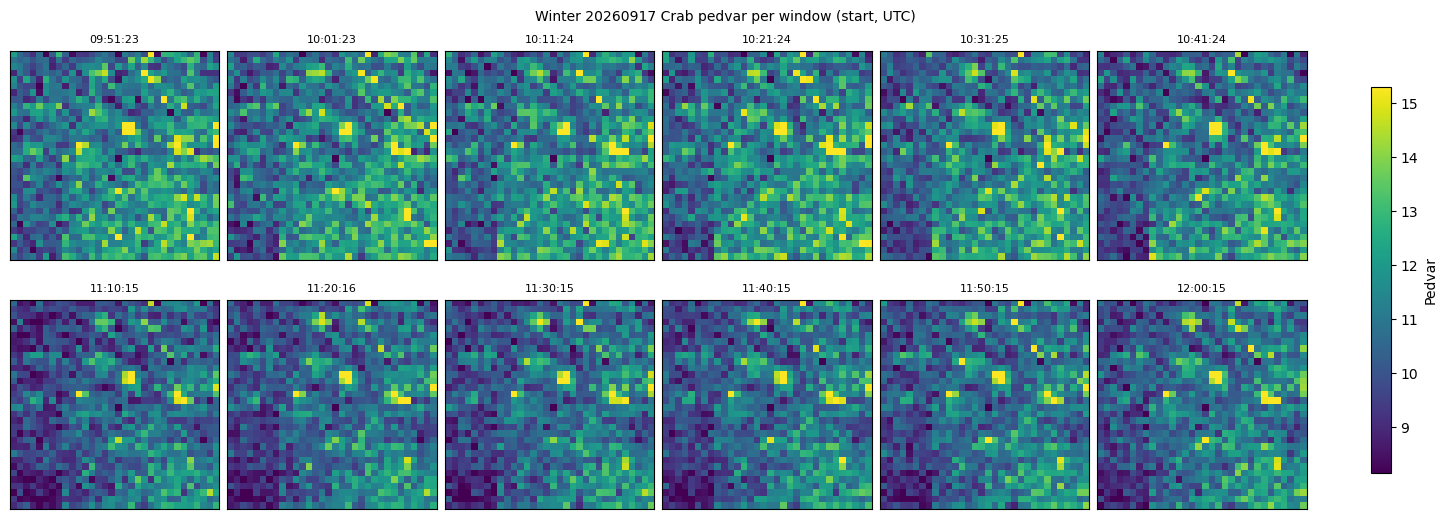

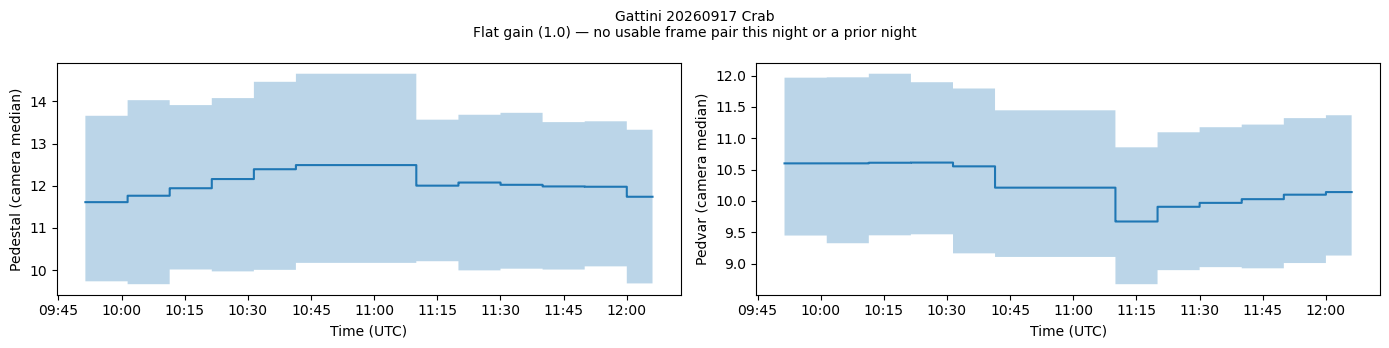

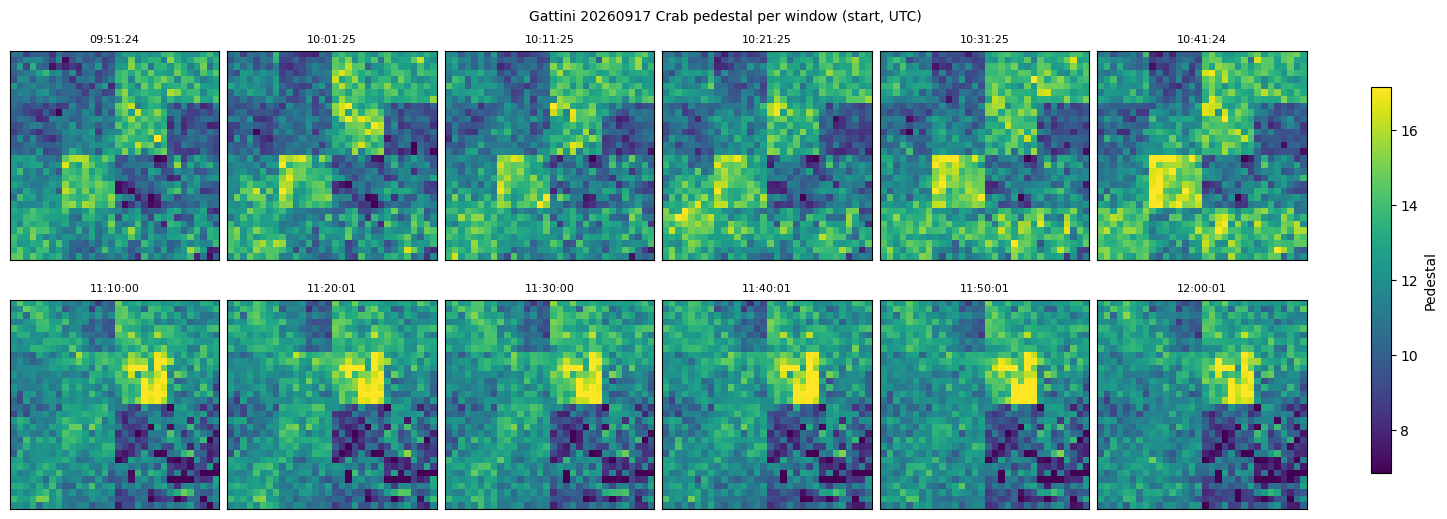

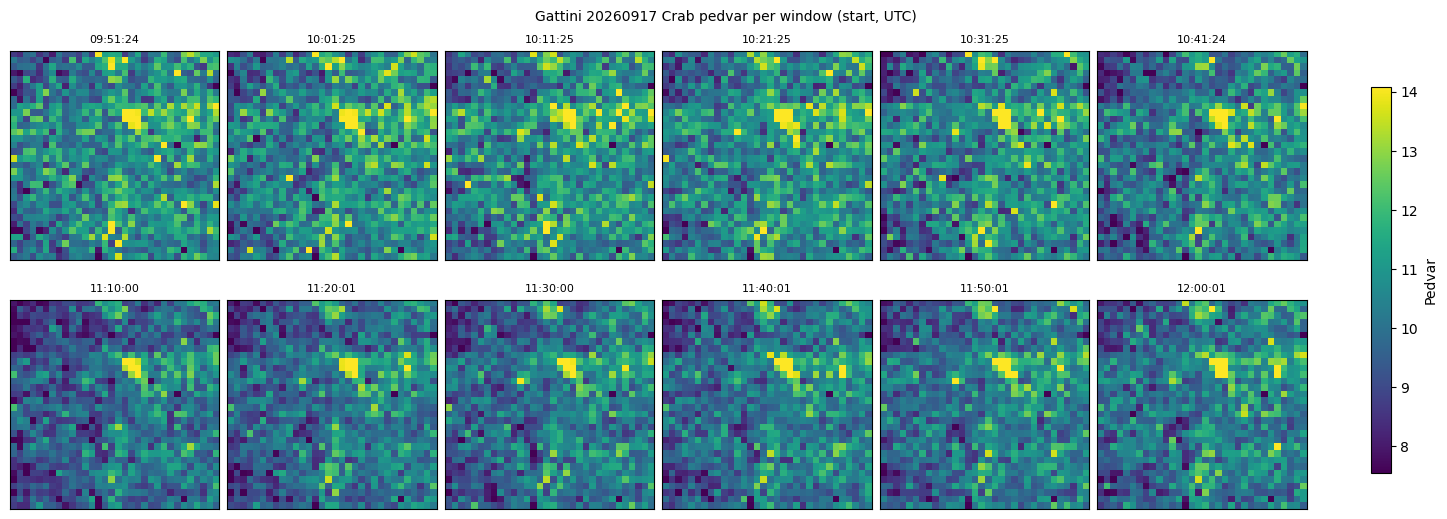

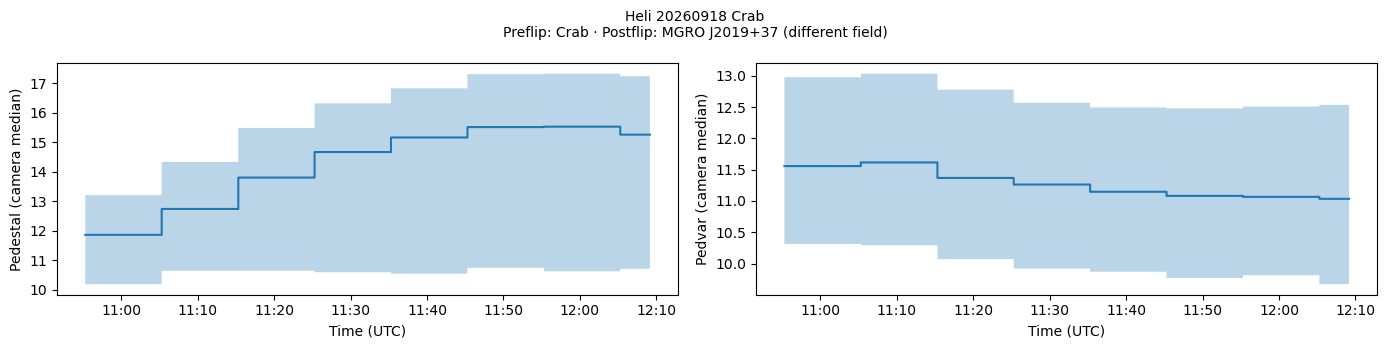

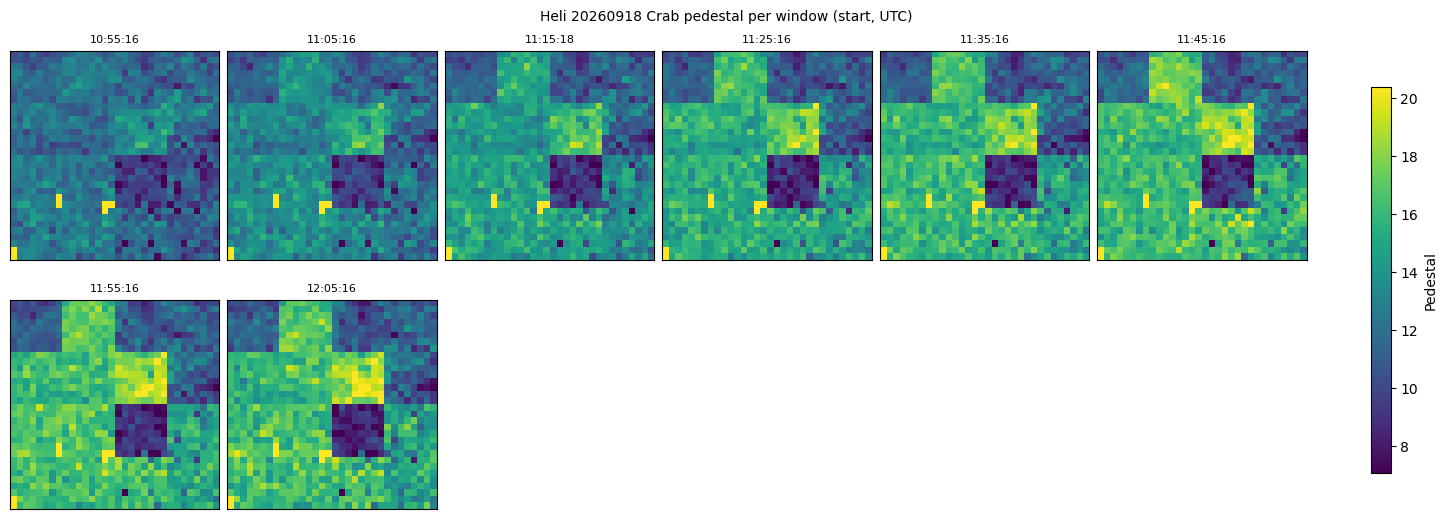

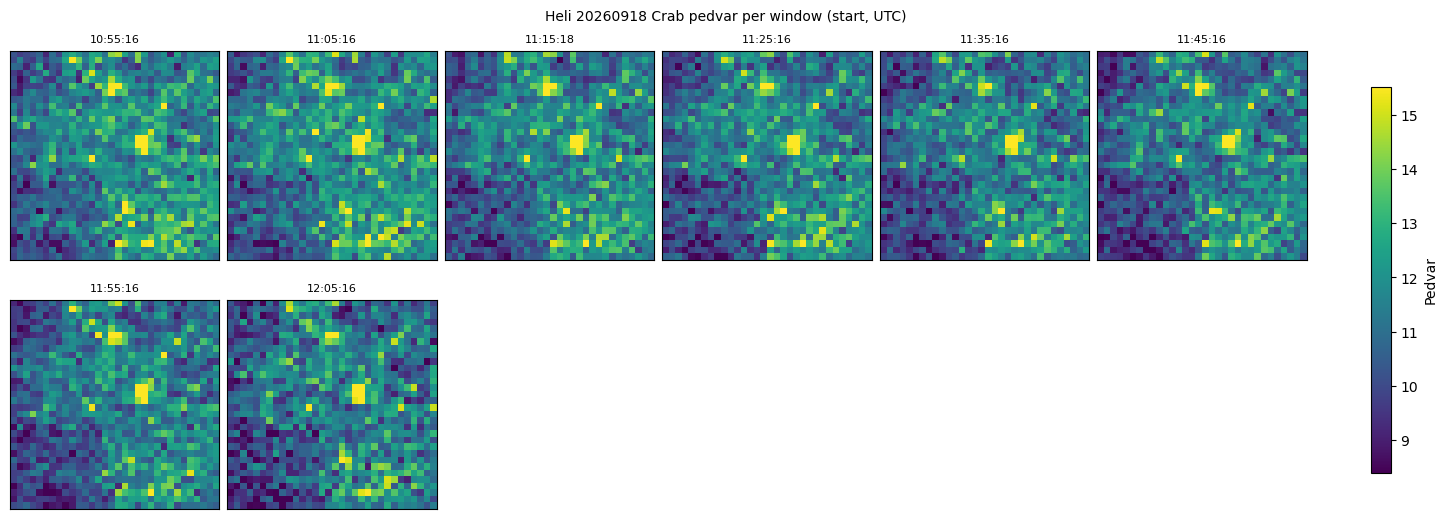

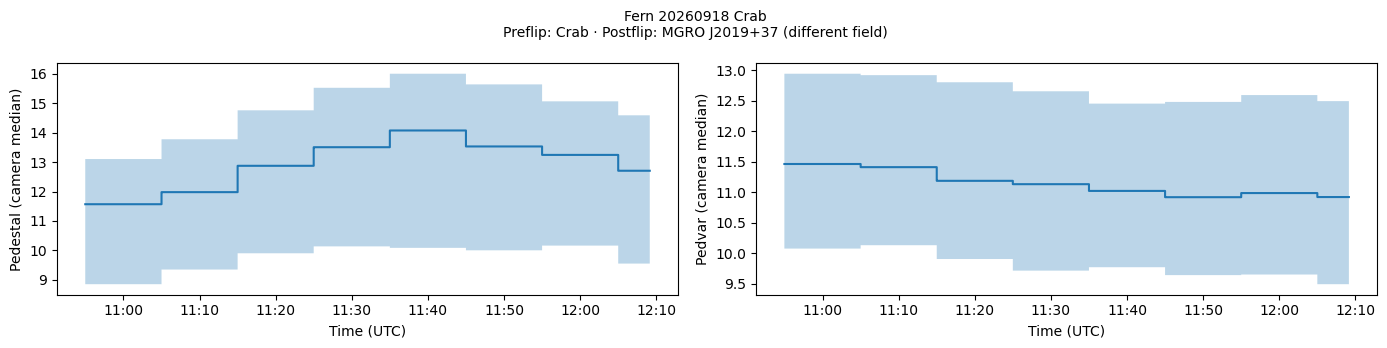

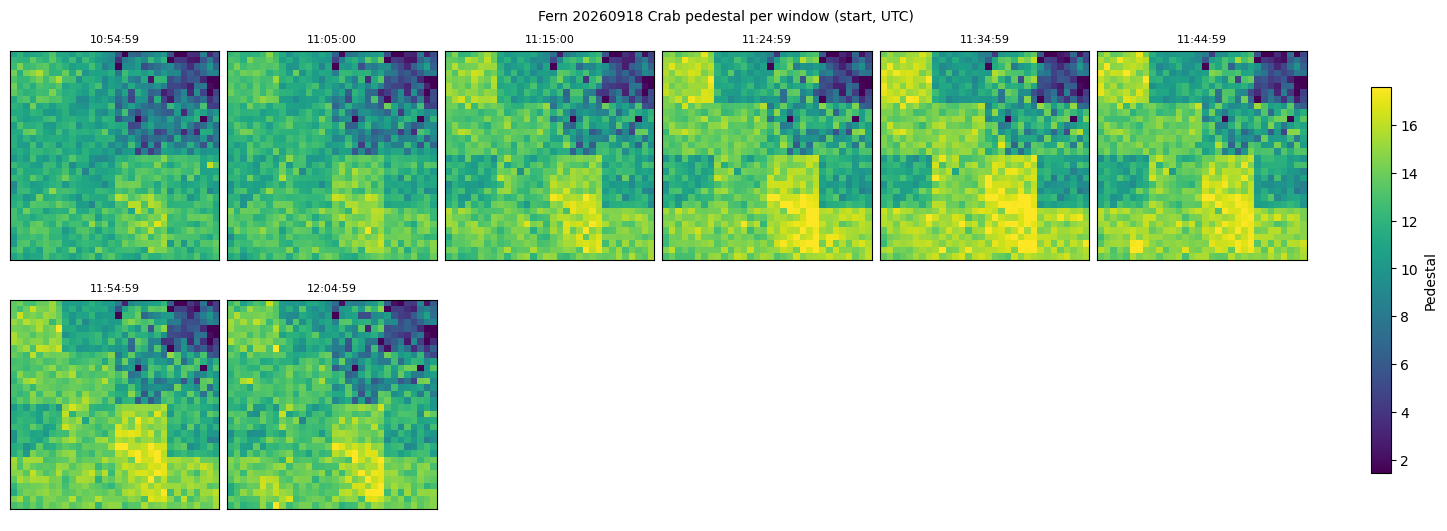

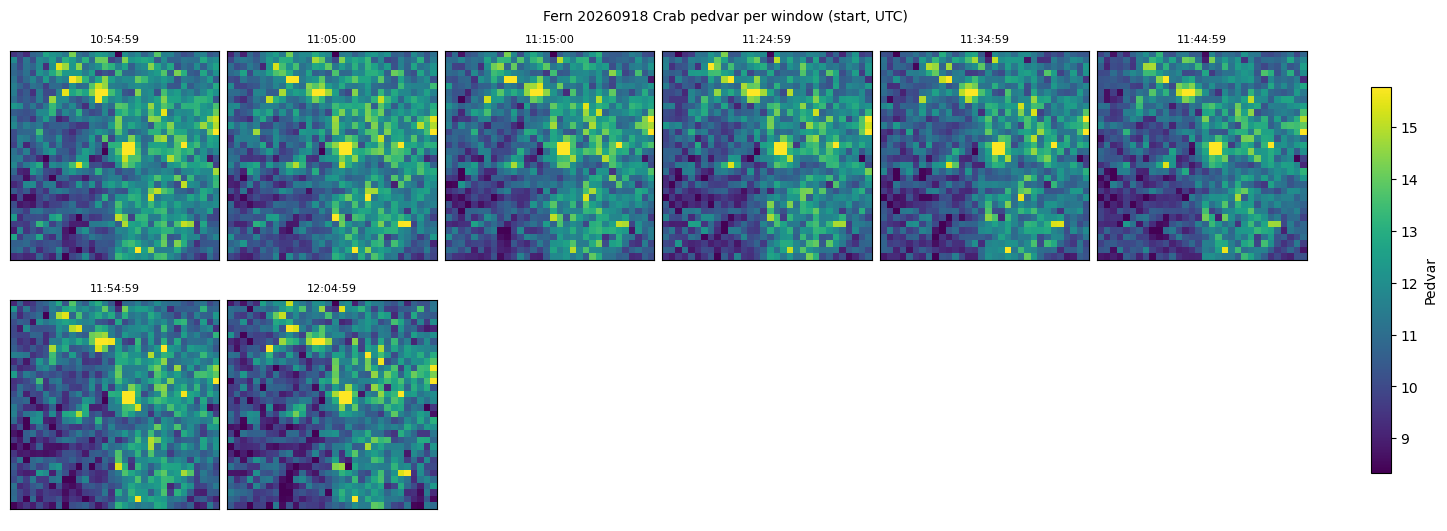

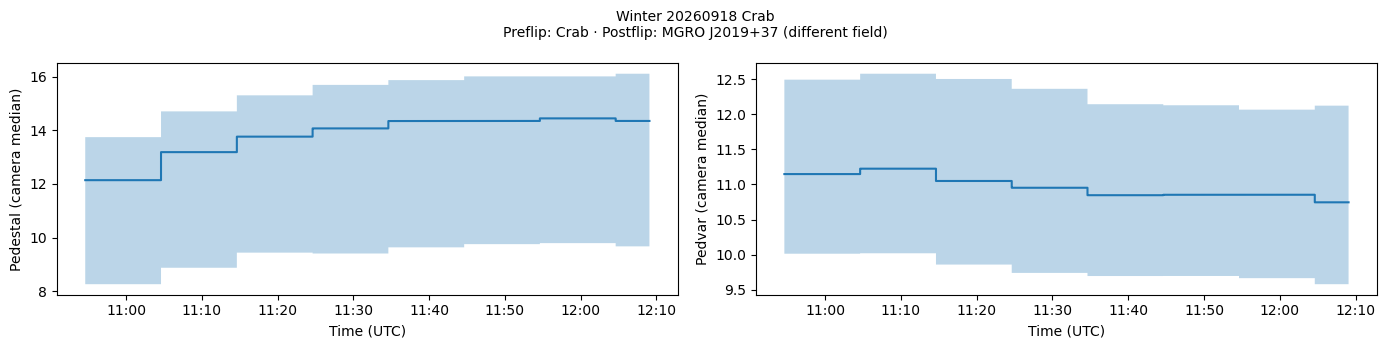

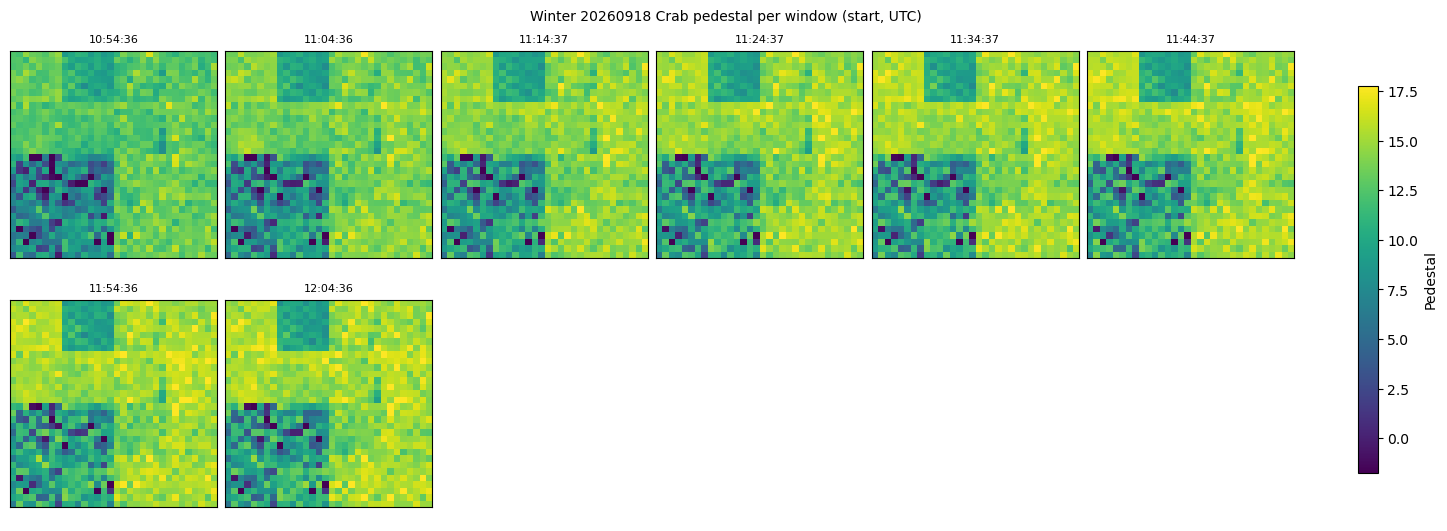

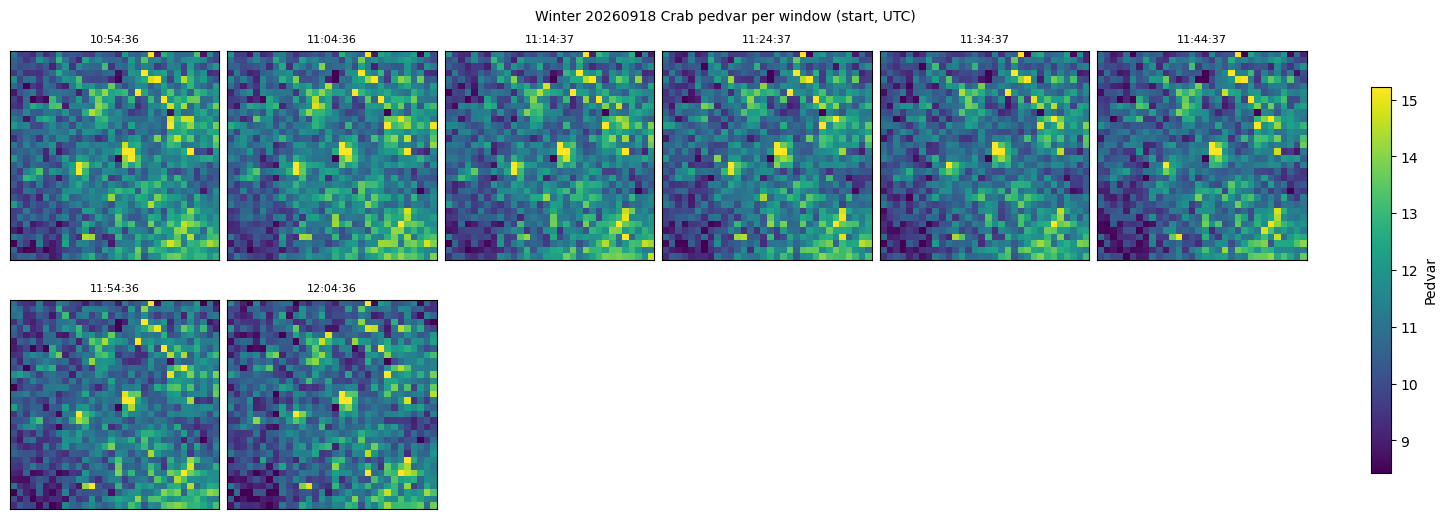

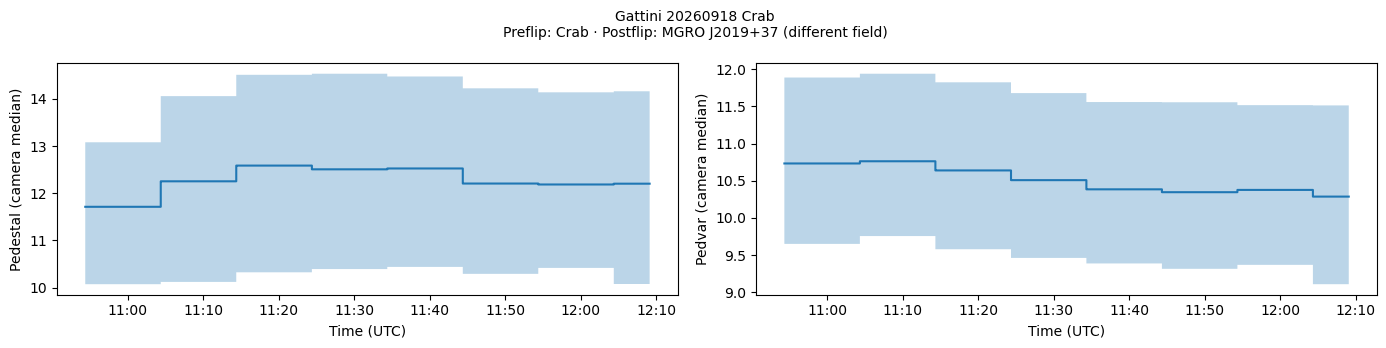

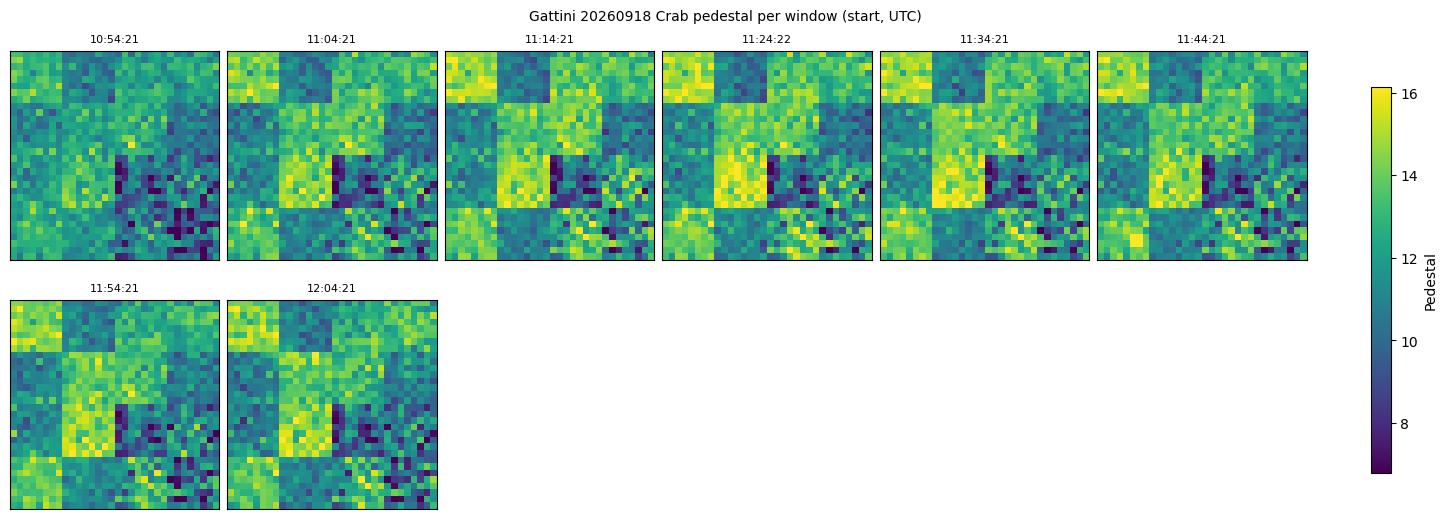

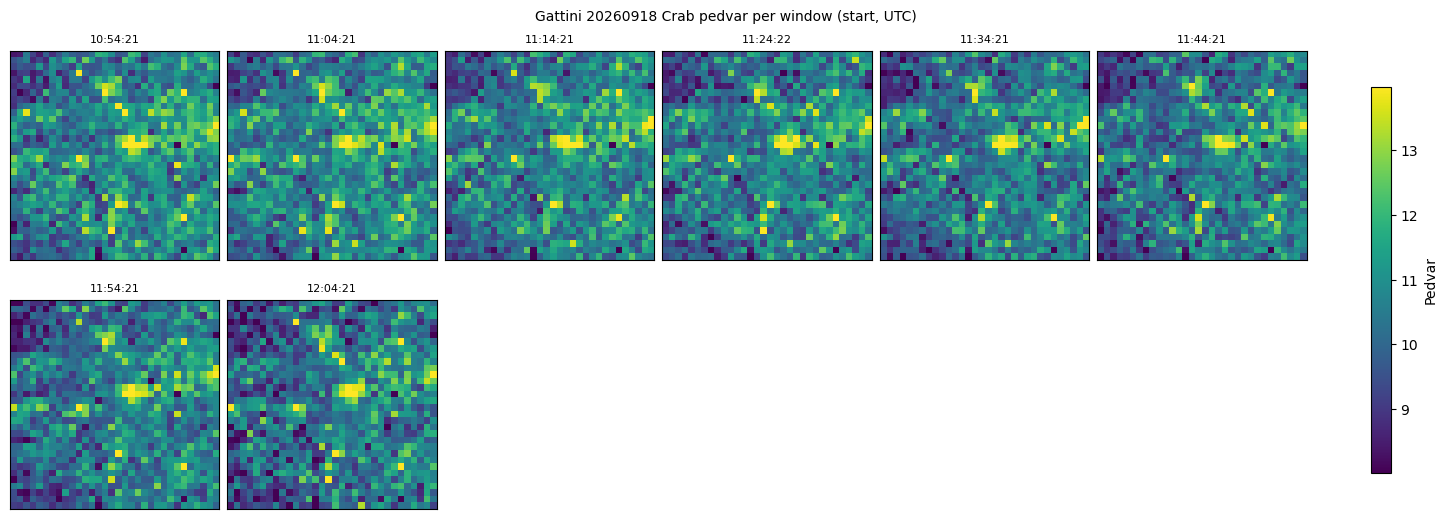

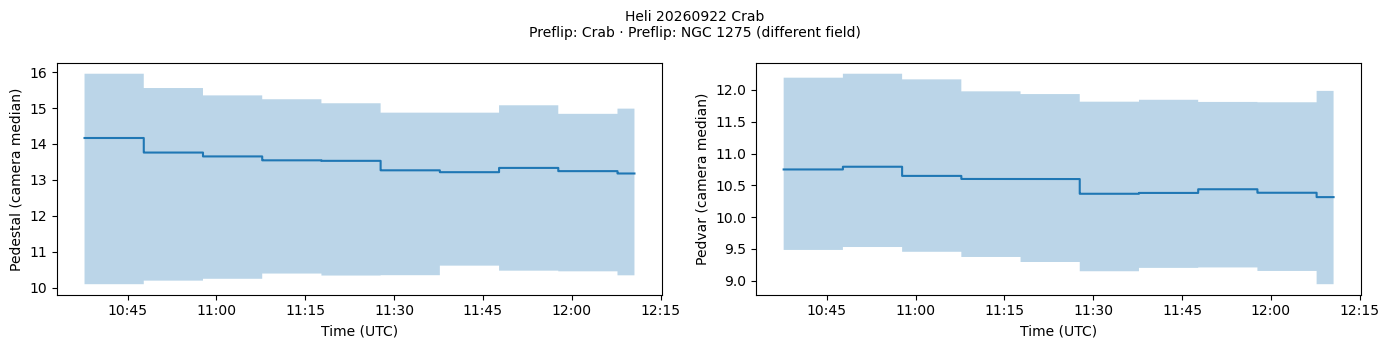

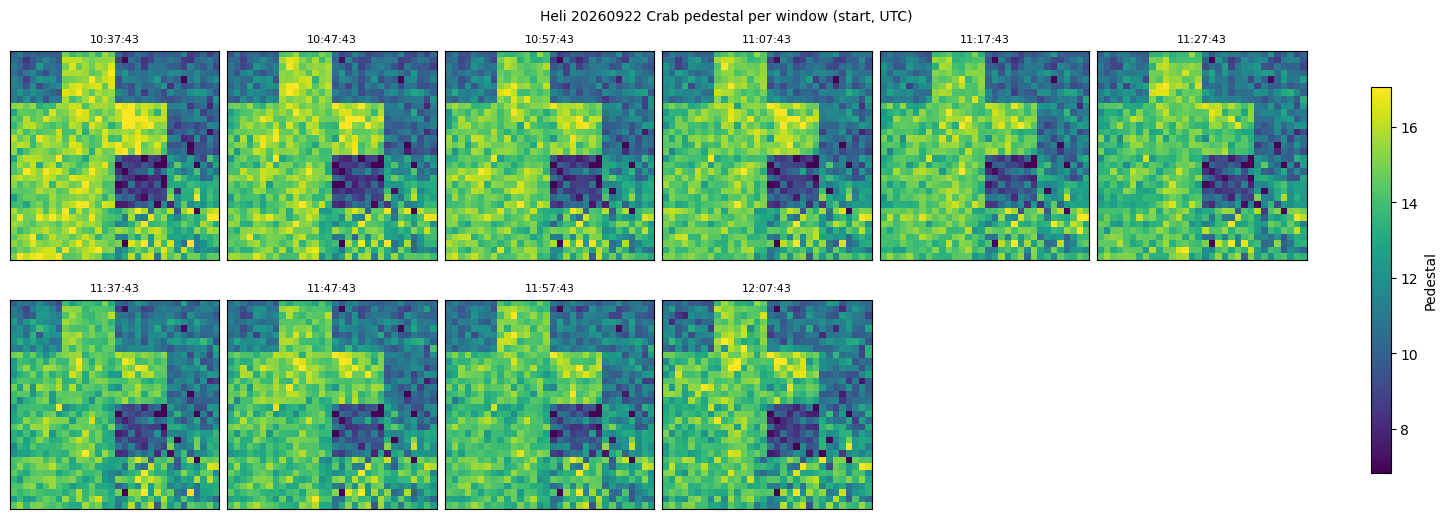

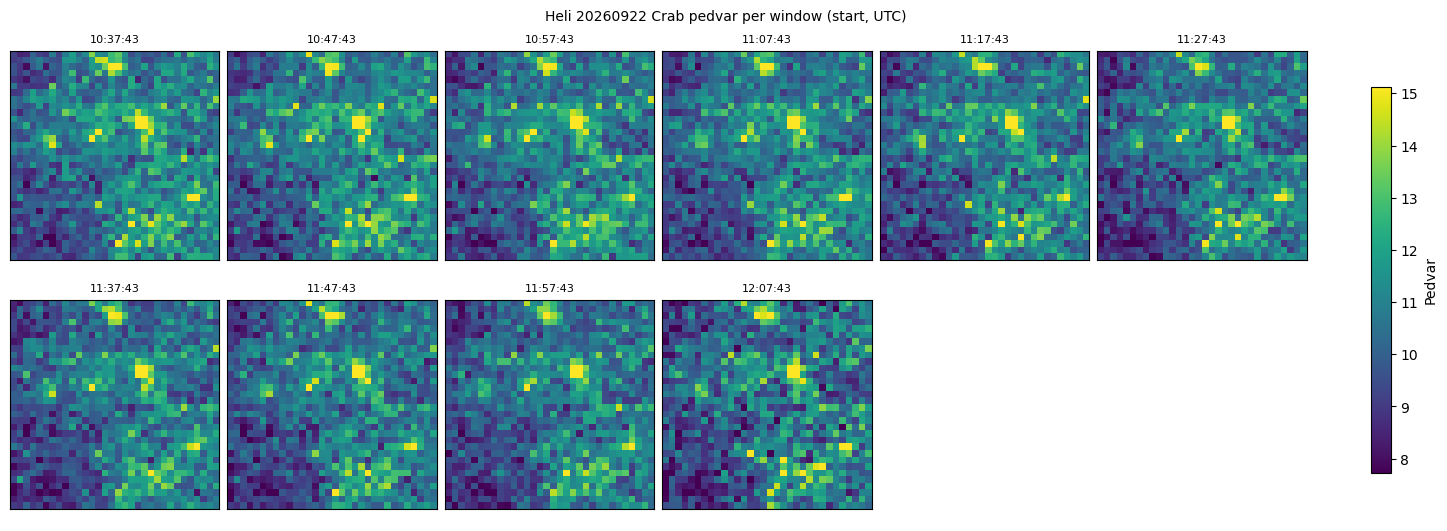

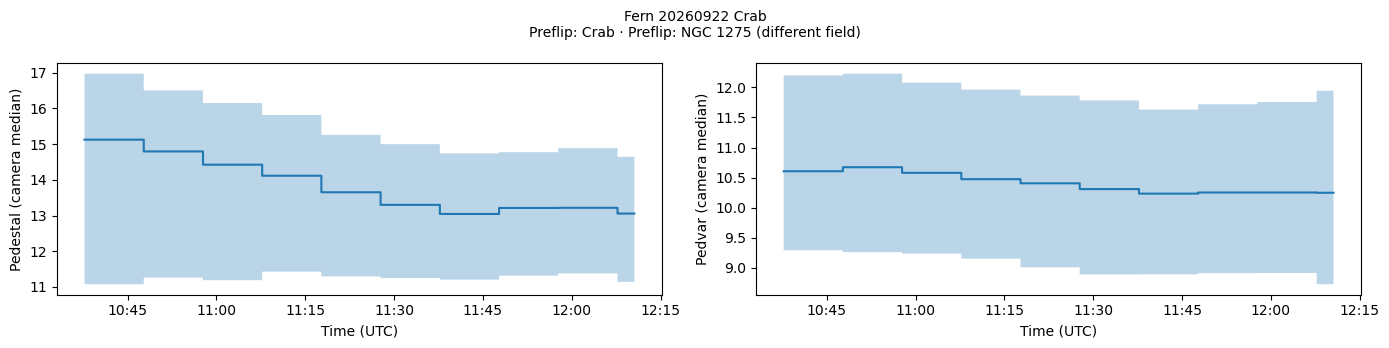

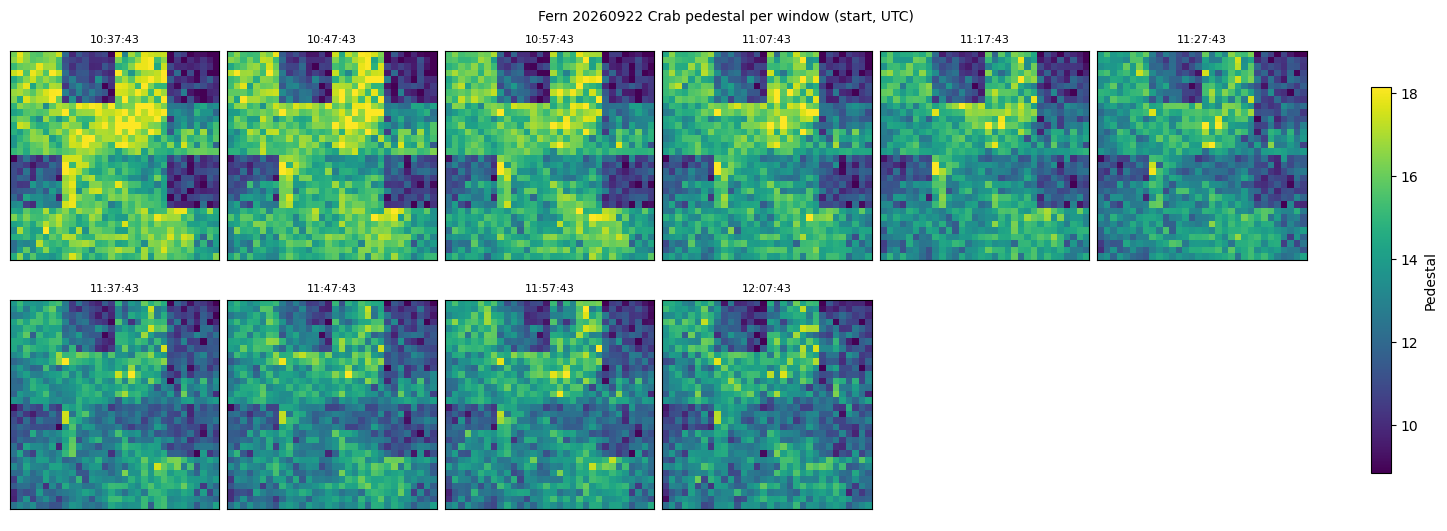

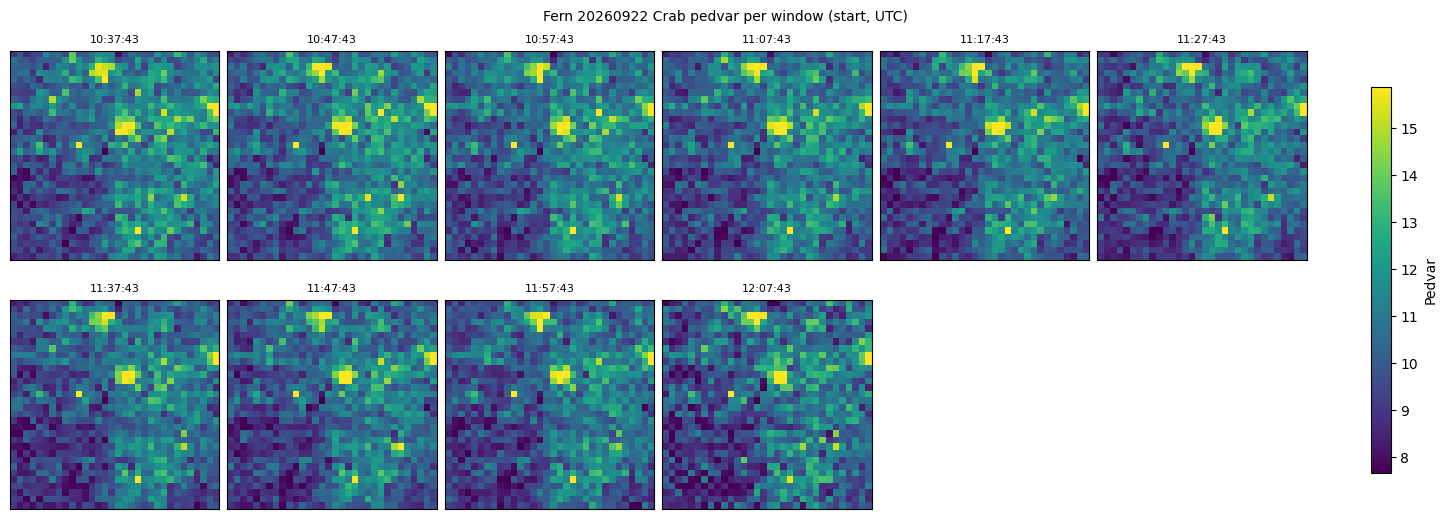

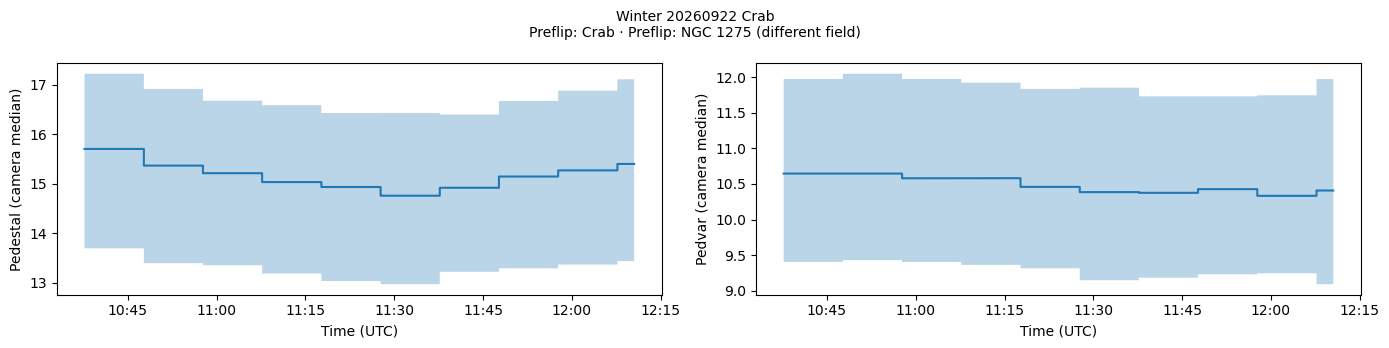

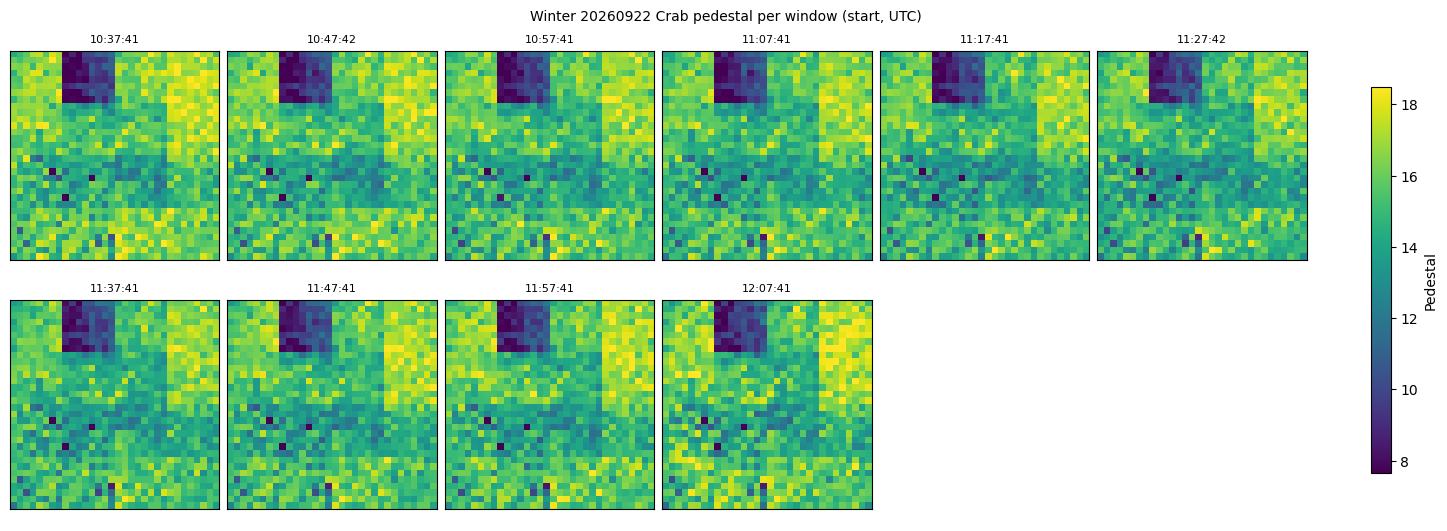

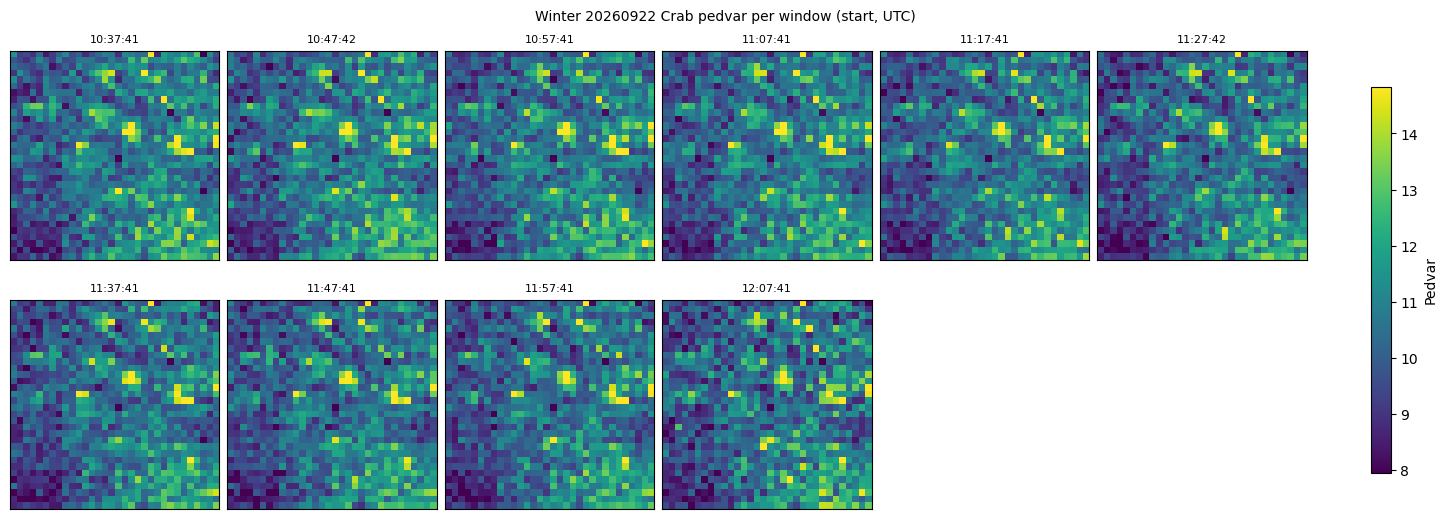

In [10]:
for date in DATES:
    for telescope in TELESCOPES:
        if ev.params_path(OUTPUT_DIR, date, telescope, SOURCE).exists():
            params, _, calib = dg.load_products(OUTPUT_DIR, date, telescope, SOURCE)
            dg.plot_calibrations(params, calib, f"{telescope} {date} {SOURCE}")
            dg.plot_calibration_windows(params, calib, f"{telescope} {date} {SOURCE}")
            plt.show()

## Rates
Frames kept after the cuts, and images with at least `MIN_NPIX` pixels after cleaning.

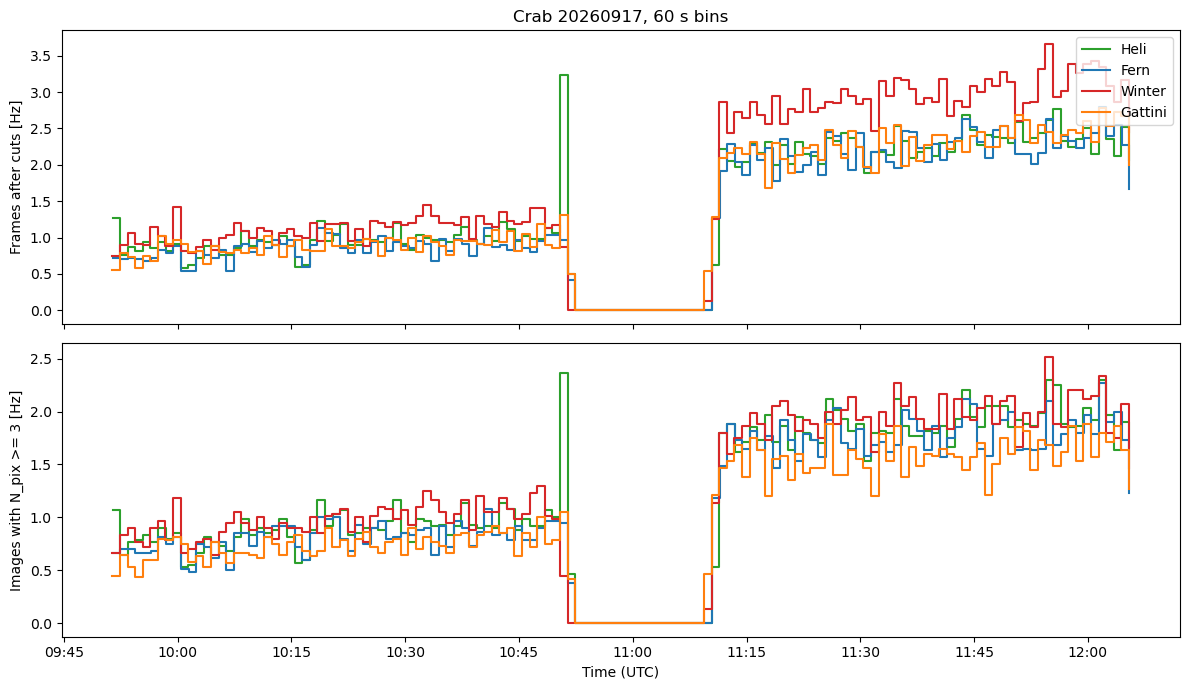

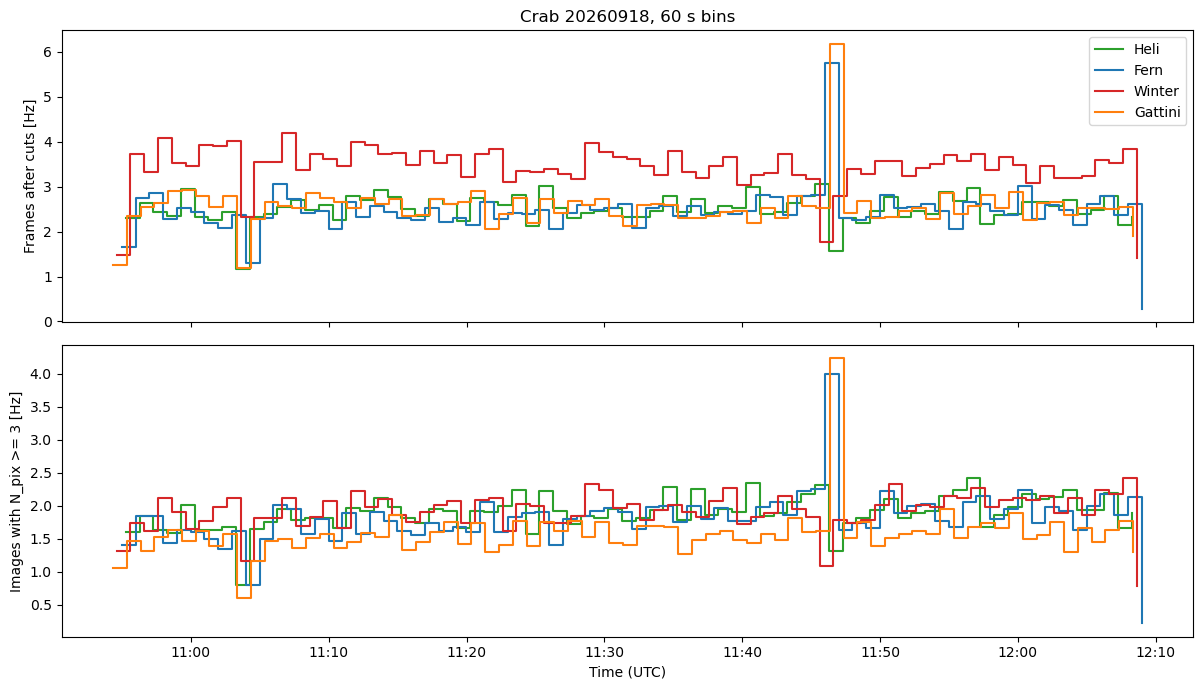

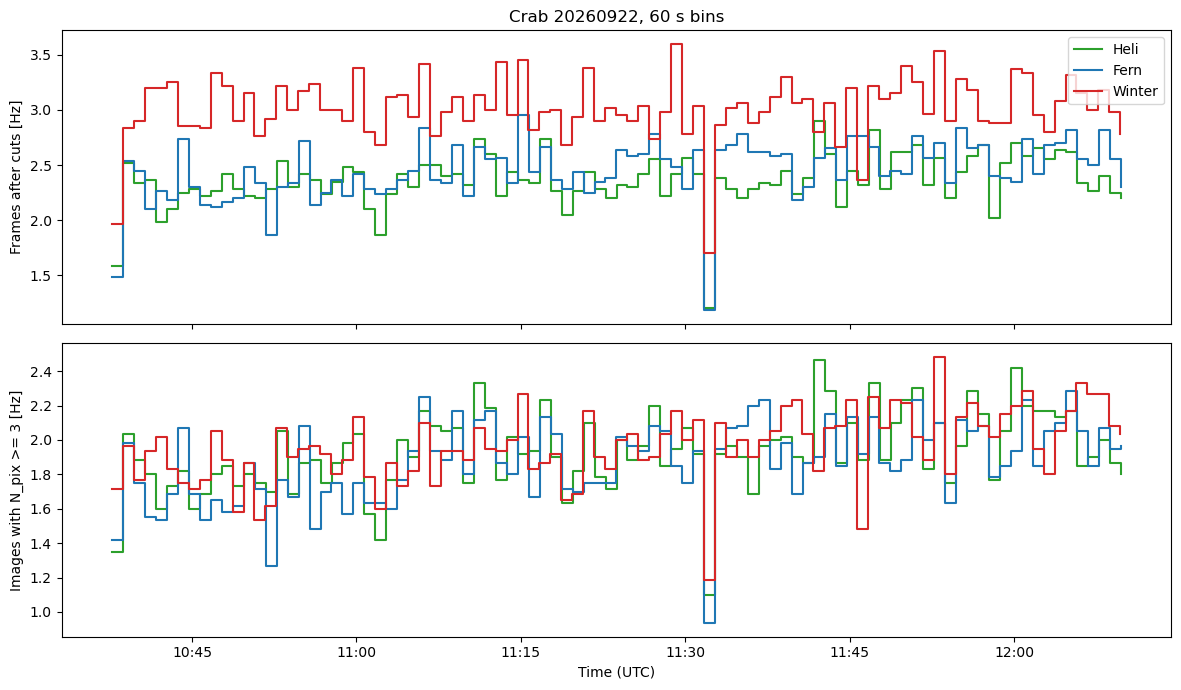

In [11]:
for date in DATES:
    dg.plot_rates(OUTPUT_DIR, date, TELESCOPES, SOURCE, min_npix=MIN_NPIX, colors=COLORS)
    plt.show()

## Timing and coincidences
Each telescope's timing offset to `REFERENCE` before and after correction, then events per telescope combination
(images matched within `COINC_WINDOW`, before any cuts; see `heap.events.build_events()`).

20260917
Winter-Heli timing offset: RMS=  0.00042 s, std= 0.00042 s
Winter-Heli corrected offset: RMS=  0.0 s, std= 0.0 s


/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


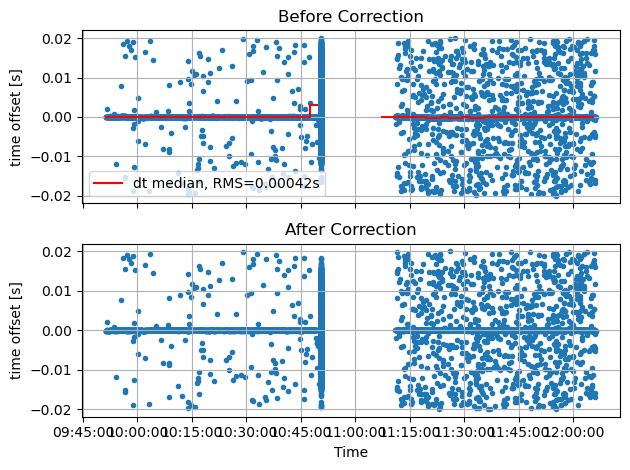

/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Winter-Fern timing offset: RMS=  8e-05 s, std= 5e-05 s
Winter-Fern corrected offset: RMS=  0.0 s, std= 0.0 s


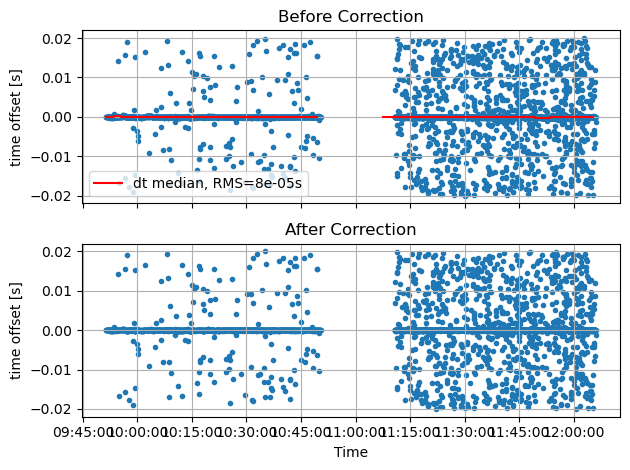

Winter-Gattini timing offset: RMS=  0.00106 s, std= 0.00104 s
Winter-Gattini corrected offset: RMS=  0.00131 s, std= 0.00128 s


/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


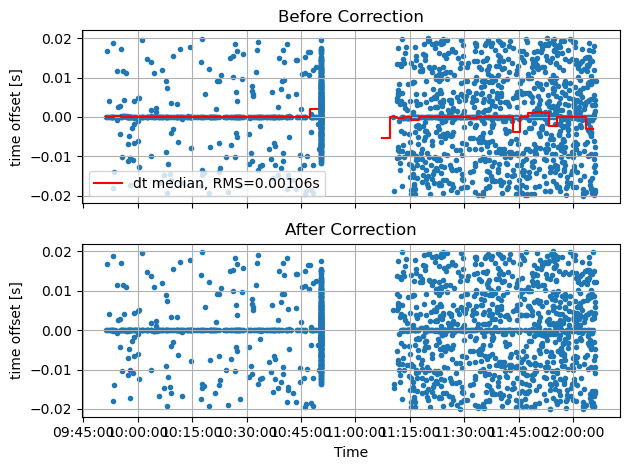

Heli-Fern within 0.001s: 4293/11106 Heli events (38.7%) and 4290/10503 Fern events (40.8%) coincident, 4312 pairs
Heli-Winter within 0.001s: 3526/11106 Heli events (31.7%) and 3457/13797 Winter events (25.1%) coincident, 4193 pairs
Heli-Gattini within 0.001s: 517/11106 Heli events (4.7%) and 443/10912 Gattini events (4.1%) coincident, 554 pairs
Fern-Winter within 0.001s: 3144/10503 Fern events (29.9%) and 3144/13797 Winter events (22.8%) coincident, 3159 pairs
Fern-Gattini within 0.001s: 244/10503 Fern events (2.3%) and 244/10912 Gattini events (2.2%) coincident, 245 pairs
Winter-Gattini within 0.001s: 481/13797 Winter events (3.5%) and 460/10912 Gattini events (4.2%) coincident, 497 pairs
6244 events; dropped 51 ambiguous groups (a telescope matched more than one image)
20260918
Winter-Heli timing offset: RMS=  0.00019 s, std= 0.00017 s
Winter-Heli corrected offset: RMS=  0.0 s, std= 0.0 s


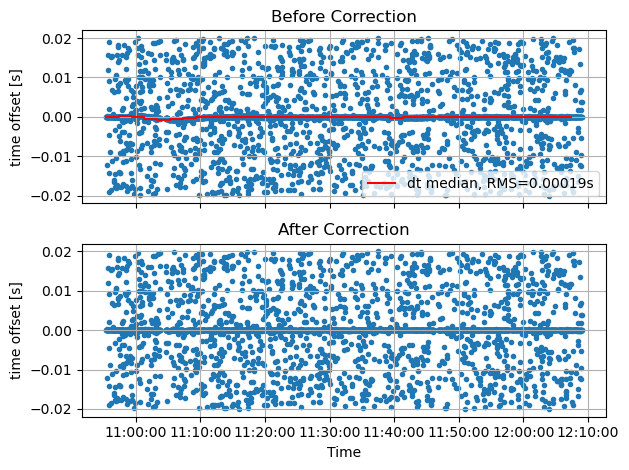

Winter-Fern timing offset: RMS=  0.00013 s, std= 0.00011 s
Winter-Fern corrected offset: RMS=  0.0 s, std= 0.0 s


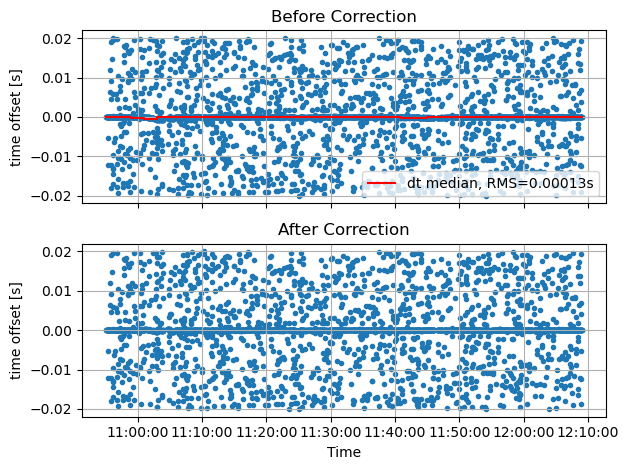

Winter-Gattini timing offset: RMS=  0.00173 s, std= 0.00171 s
Winter-Gattini corrected offset: RMS=  0.00093 s, std= 0.00092 s


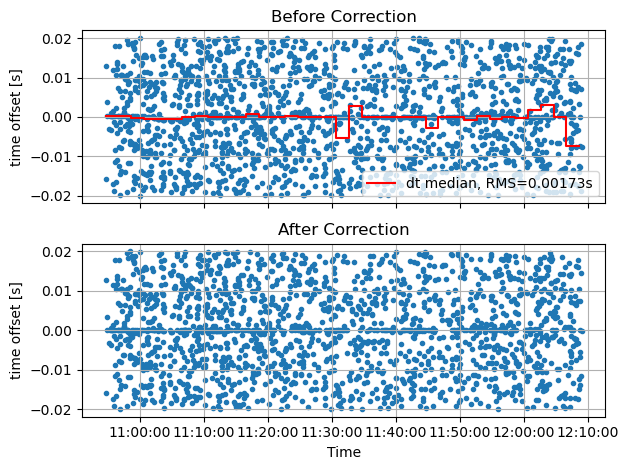

Heli-Fern within 0.001s: 3695/11128 Heli events (33.2%) and 3695/11065 Fern events (33.4%) coincident, 3713 pairs
Heli-Winter within 0.001s: 2559/11128 Heli events (23.0%) and 2571/15410 Winter events (16.7%) coincident, 2579 pairs
Heli-Gattini within 0.001s: 314/11128 Heli events (2.8%) and 313/11473 Gattini events (2.7%) coincident, 315 pairs
Fern-Winter within 0.001s: 2504/11065 Fern events (22.6%) and 2518/15410 Winter events (16.3%) coincident, 2526 pairs
Fern-Gattini within 0.001s: 351/11065 Fern events (3.2%) and 366/11473 Gattini events (3.2%) coincident, 1958 pairs
Winter-Gattini within 0.001s: 307/15410 Winter events (2.0%) and 306/11473 Gattini events (2.7%) coincident, 308 pairs
5401 events; dropped 54 ambiguous groups (a telescope matched more than one image)
20260922
Winter-Heli timing offset: RMS=  6e-05 s, std= 4e-05 s
Winter-Heli corrected offset: RMS=  0.0 s, std= 0.0 s


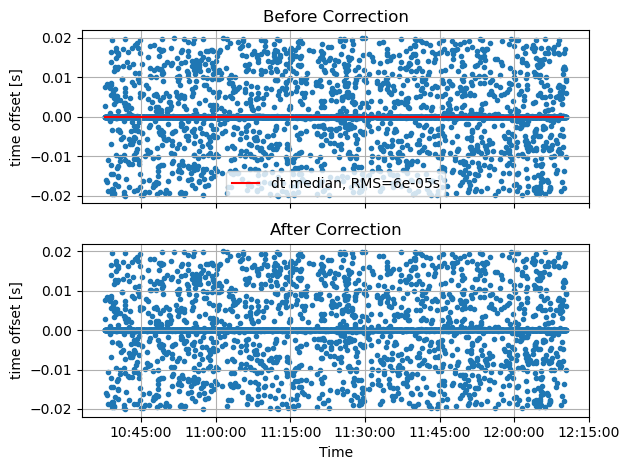

Winter-Fern timing offset: RMS=  9e-05 s, std= 7e-05 s
Winter-Fern corrected offset: RMS=  0.0 s, std= 0.0 s


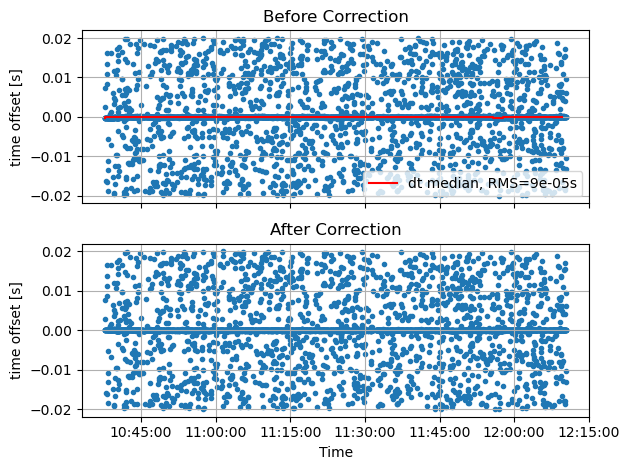

Heli-Fern within 0.001s: 4704/13173 Heli events (35.7%) and 4702/13673 Fern events (34.4%) coincident, 4755 pairs
Heli-Winter within 0.001s: 3172/13173 Heli events (24.1%) and 3175/16825 Winter events (18.9%) coincident, 3195 pairs
Fern-Winter within 0.001s: 3223/13673 Fern events (23.6%) and 3227/16825 Winter events (19.2%) coincident, 3249 pairs
6409 events; dropped 57 ambiguous groups (a telescope matched more than one image)


,20260917,20260918,20260922
Telescope,,,
Fern + Gattini,22,31,0
Fern + Gattini + Heli,19,20,0
Fern + Gattini + Heli + Winter,197,101,0
Fern + Gattini + Winter,4,7,0
Fern + Heli,1860,1877,2376
Fern + Heli + Winter,2165,1637,2257
Fern + Winter,731,722,913
Gattini + Heli,110,107,0
Gattini + Heli + Winter,106,79,0


In [12]:
combos = {}
for date in DATES:
    print(date)
    events = ev.build_array_events(OUTPUT_DIR, RAW_DATA_DIR / date, date, SOURCE, TELESCOPES, REFERENCE, window=COINC_WINDOW, plotting=True)
    if events is not None and len(events):
        combos[date] = events.groupby("Event").Telescope.agg(lambda t: " + ".join(sorted(t))).value_counts()
pd.DataFrame(combos).fillna(0).astype(int)